In [341]:
print("Versão do Python:")
!python --version

Versão do Python:
Python 3.14.4


## Bibliotecas requeridas


In [342]:
!pip install -r requirements.txt

## Importa Bibliotecas base

In [343]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Ler arquivos CSV's

### Carregamento e Inspeção dos Dados
- **Importação:** Leitura dos arquivos CSV de cadastros, informações e pagamentos utilizando a biblioteca Pandas com separador `;`.
- **Visualização:** Uso do método `display(.head())` para exibir as cinco primeiras linhas de cada base.
- **Validação:** Conferência inicial para garantir o carregamento correto e inspecionar a estrutura preliminar dos dados.

In [344]:
base_cadastros = pd.read_csv("data/base_cadastral.csv", sep=";" )
base_info = pd.read_csv("data/base_info.csv", sep=";" )
base_pagamentos_desenvolvimento = pd.read_csv("data/base_pagamentos_desenvolvimento.csv", sep=";" )
base_pagamentos_teste = pd.read_csv("data/base_pagamentos_teste.csv", sep=";" )

display(base_cadastros.head())
display(base_info.head())
display(base_pagamentos_desenvolvimento.head())
display(base_pagamentos_teste.head())

,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62


,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99


### Conversão de Tipos Temporais
- **Transformação:** Conversão das colunas de datas (`EMISSAO`, `VENCIMENTO`, `PAGAMENTO` e `CADASTRO`) para o tipo `datetime`.
- **Tratamento de Erros:** Utilização do parâmetro `errors="coerce"` para forçar a conversão, atribuindo `NaT` a valores inválidos.
- **Objetivo:** Padronizar as informações temporais das bases para possibilitar cálculos de prazos e análises cronológicas.

In [345]:
base_pagamentos_desenvolvimento["DATA_EMISSAO_DOCUMENTO"] = pd.to_datetime(base_pagamentos_desenvolvimento["DATA_EMISSAO_DOCUMENTO"], errors="coerce")
base_pagamentos_desenvolvimento["DATA_PAGAMENTO"] = pd.to_datetime(base_pagamentos_desenvolvimento["DATA_PAGAMENTO"], errors="coerce")
base_pagamentos_desenvolvimento["DATA_VENCIMENTO"] = pd.to_datetime(base_pagamentos_desenvolvimento["DATA_VENCIMENTO"], errors="coerce")

base_pagamentos_teste["DATA_EMISSAO_DOCUMENTO"] = pd.to_datetime(base_pagamentos_teste["DATA_EMISSAO_DOCUMENTO"], errors="coerce")
base_pagamentos_teste["DATA_VENCIMENTO"] = pd.to_datetime(base_pagamentos_teste["DATA_VENCIMENTO"], errors="coerce")

base_cadastros["DATA_CADASTRO"] = pd.to_datetime(base_cadastros["DATA_CADASTRO"], errors="coerce")

## Criação da Variável Alvo e Análise de Classes


- **Definição:** Criação da flag `INADIMPLENTE`, classificando como 1 (verdadeiro) os pagamentos realizados com 5 ou mais dias de atraso após o vencimento.
- **Conversão:** Transformação da condição booleana em formato inteiro (0 e 1) através do método `.astype(int)`.
- **Distribuição:** Utilização do `.value_counts()` para verificar a proporção de classes e avaliar o nível de desbalanceamento da variável alvo.

In [346]:
base_pagamentos_desenvolvimento["INADIMPLENTE"] = (base_pagamentos_desenvolvimento["DATA_PAGAMENTO"] >= base_pagamentos_desenvolvimento["DATA_VENCIMENTO"]+pd.Timedelta(days=5)).astype(int)
base_pagamentos_desenvolvimento["INADIMPLENTE"].value_counts()

INADIMPLENTE
0    71978
1     5436
Name: count, dtype: int64

## Marge Base

- **Mesclagem:** Criação da `base_model` unindo os dados de pagamentos, informações mensais e cadastros via `pd.merge` (left join).
- **Gráfico:** Plotagem da distribuição da variável alvo `INADIMPLENTE` utilizando um gráfico de barras com a biblioteca Seaborn.
- **Inspeção:** Uso do método `.info()` na base final consolidada para verificar os tipos de variáveis e a contagem de valores nulos.

<class 'pandas.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_CLIENTE              77414 non-null  int64         
 1   SAFRA_REF               77414 non-null  str           
 2   DATA_EMISSAO_DOCUMENTO  77414 non-null  datetime64[us]
 3   DATA_PAGAMENTO          77414 non-null  datetime64[us]
 4   DATA_VENCIMENTO         77414 non-null  datetime64[us]
 5   VALOR_A_PAGAR           76244 non-null  float64       
 6   TAXA                    77414 non-null  float64       
 7   INADIMPLENTE            77414 non-null  int64         
 8   RENDA_MES_ANTERIOR      71282 non-null  float64       
 9   NO_FUNCIONARIOS         69827 non-null  float64       
 10  DATA_CADASTRO           77414 non-null  datetime64[us]
 11  DDD                     70000 non-null  str           
 12  FLAG_PF                 219 non-null    str           
 1

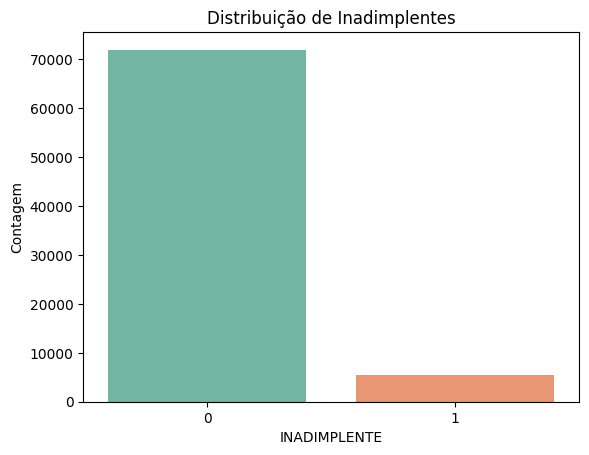

In [347]:
base_mensal=pd.merge(base_pagamentos_desenvolvimento, base_info,  on=["ID_CLIENTE", "SAFRA_REF"], how="left")
base_model = pd.merge(base_mensal, base_cadastros, on=["ID_CLIENTE"], how="left")
sns.barplot(x=base_model["INADIMPLENTE"].value_counts().index, y=base_model["INADIMPLENTE"].value_counts().values,  hue=base_model["INADIMPLENTE"].value_counts().index,palette="Set2", legend=False)

plt.title("Distribuição de Inadimplentes")
plt.ylabel("Contagem")
base_model.info()

### Consolidação da Base de Submissão
- **Enriquecimento de Dados:** Realização de múltiplos cruzamentos (`pd.merge`) para unificar as informações de pagamentos, dados cadastrais e variáveis auxiliares em um único DataFrame consolidado.
- **Join:** Utilização do método `how="left"` para preservar a totalidade dos registros da base de pagamentos (tabela fato), garantindo que nenhum ID de cliente necessário para a submissão seja descartado durante o cruzamento com as tabelas de dimensão.

In [348]:
base_mensal=pd.merge(base_pagamentos_teste, base_info,  on=["ID_CLIENTE", "SAFRA_REF"], how="left")
base_submit = pd.merge(base_mensal, base_cadastros, on=["ID_CLIENTE"], how="left")
base_submit.info()

<class 'pandas.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_CLIENTE              12275 non-null  int64         
 1   SAFRA_REF               12275 non-null  str           
 2   DATA_EMISSAO_DOCUMENTO  12275 non-null  datetime64[us]
 3   DATA_VENCIMENTO         12275 non-null  datetime64[us]
 4   VALOR_A_PAGAR           12144 non-null  float64       
 5   TAXA                    12275 non-null  float64       
 6   RENDA_MES_ANTERIOR      11549 non-null  float64       
 7   NO_FUNCIONARIOS         11108 non-null  float64       
 8   DATA_CADASTRO           12237 non-null  datetime64[us]
 9   DDD                     10898 non-null  str           
 10  FLAG_PF                 47 non-null     str           
 11  SEGMENTO_INDUSTRIAL     12021 non-null  str           
 12  DOMINIO_EMAIL           12067 non-null  str           
 1

## Divisão Temporal (Treino e Teste)

- **Estratégia OOT:** Separação cronológica (`SAFRA_REF`), reservando as 5 safras mais recentes para teste e as demais para treino.
- **Validação:** Exibição dos limites temporais, volume de linhas e proporção entre os conjuntos para confirmar a integridade da divisão.

In [ ]:
safras_ordenadas = sorted(base_model["SAFRA_REF"].unique())

n_test_safras = 5

safras_train = safras_ordenadas[:-n_test_safras]
safras_test  = safras_ordenadas[-n_test_safras:]

train = base_model[base_model["SAFRA_REF"].isin(safras_train)]
test  = base_model[base_model["SAFRA_REF"].isin(safras_test)]

print(f"Safras treino: {safras_train[0]} -> {safras_train[-1]}")
print(f"Safras teste:  {safras_test[0]} -> {safras_test[-1]}")
print(f"Treino: {len(train):,} linhas | Teste: {len(test):,} linhas")
print(f"Proporção Teste/Treino: {len(test)/len(train):.2%}")


Safras treino: 2018-08 -> 2021-01
Safras teste:  2021-02 -> 2021-06
Treino: 65,540 linhas | Teste: 11,874 linhas
Proporção Teste/Treino: 18.12%


## Transformador Personalizado de Imputação (Scikit-Learn)


- **Classe:** Criação do transformador `ImputacaoFLAG_PF` herdando propriedades do Scikit-Learn para integração em fluxos de `Pipeline`.
- **Mapeamento:** Conversão categórica da coluna `FLAG_PF`, atribuindo 1 (Pessoa Física) para "X" e 0 (Pessoa Jurídica) para valores nulos.
- **Processamento:** Aplicação da regra de substituição através do método `transform` operando em uma cópia segura dos dados.

In [350]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

class ImputacaoFLAG_PF(BaseEstimator, TransformerMixin):
    def __init__(self, col="FLAG_PF", PJ=0, PF=1):
        self.col = col
        self.PF_PJ = {"X":PF, np.nan:PJ}

    def fit(self, X,y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()
        X[self.col] = X[self.col].map(self.PF_PJ)
        
        return X


### Imputação Categórica de Valores Ausentes
- **Objetivo:** Criação do transformador `ImputacaoValueUnknown` para lidar com dados nulos em colunas específicas (ex: `DOMINIO_EMAIL`).
- **Transformação:** Substituição segura de valores faltantes (`NaN`) por uma string de controle (default: "UNKNOWN") utilizando `.fillna()`.

In [351]:
class ImputacaoValueUnknown(BaseEstimator, TransformerMixin):
    def __init__(self, col="DOMINIO_EMAIL", fill_value="UNKNOWN"):
        self.col = col
        self.fill_value = fill_value

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()
        
        X[self.col] = X[self.col].fillna(self.fill_value)
        
        return X

### Imputação Hierárquica de Valores Ausentes
- **Estratégia:** Cálculo de medianas em três níveis de granularidade (Cliente+Safra, Cliente e Global) durante o método `fit`.
- **Transformação:** Preenchimento sequencial e hierárquico dos nulos (`NaN`), garantindo a substituição pelo valor mais específico disponível.
- **Limpeza:** Remoção automática das colunas auxiliares de mediana geradas após as operações de mesclagem (`merge`).

In [352]:
class ImputacaoHierarquicaValor(BaseEstimator, TransformerMixin):
    def __init__(self, col="VALOR_A_PAGAR"):
        self.col = col
        
    def fit(self, X, y=None):
        self.med_cs_ = X.groupby(["ID_CLIENTE", "SAFRA_REF"])[self.col].median().reset_index()
        self.med_cs_.columns = ["ID_CLIENTE", "SAFRA_REF", "med_cs"]
        
        self.med_c_ = X.groupby("ID_CLIENTE")[self.col].median().reset_index()
        self.med_c_.columns = ["ID_CLIENTE", "med_c"]
        
        self.med_global_ = X[self.col].median()
        
        return self

    def transform(self, X):
        X = X.copy()
        
        X = X.merge(self.med_cs_, on=["ID_CLIENTE", "SAFRA_REF"], how="left")
        X = X.merge(self.med_c_, on="ID_CLIENTE", how="left")
        
        # Imputação Hierárquica
        X[self.col] = X[self.col].fillna(X["med_cs"])
        X[self.col] = X[self.col].fillna(X["med_c"])
        X[self.col] = X[self.col].fillna(self.med_global_)
        
        X = X.drop(columns=["med_cs", "med_c"])
        
        return X

### Imputação de CEP pela Moda
- **Tratamento Inicial:** Substituição de strings inválidas ('na') por nulos matemáticos (`np.nan`) e conversão segura para formato inteiro (`Int16`).
- **Aprendizado:** Cálculo do valor mais frequente (moda) da distribuição da coluna alvo (ex: `CEP_2_DIG`) durante o método `fit`.
- **Transformação:** Aplicação da limpeza e tipagem na base de dados, seguida pelo preenchimento dos valores ausentes utilizando a moda previamente calculada.

In [353]:
class ImputacaoCEP2(BaseEstimator, TransformerMixin):
    def __init__(self, col="CEP_2_DIG"):
        self.col = col

    def fit(self, X, y=None):
        cep_temp = X[self.col].replace('na', np.nan).astype("Int16")
        self.moda_ = cep_temp.mode()[0]
        return self

    def transform(self, X):
        X = X.copy()
        X[self.col] = X[self.col].replace('na', np.nan).astype("Int16")
        X[self.col] = X[self.col].fillna(self.moda_)
        return X

### Imputação Geográfica de DDD Baseada em CEP
- **Mapeamento e Limpeza:** Criação de dicionário relacional entre faixas de CEP e DDD, remoção de caracteres não numéricos e invalidação de códigos fora da regra de negócio.
- **Transformação:** Preenchimento inteligente de valores nulos na coluna `DDD` através do mapeamento geográfico reverso derivado da coluna `CEP_2_DIG`.
- **Padronização:** Estruturação robusta para pipelines Scikit-Learn, retornando os dados higienizados e devidamente tipados no formato inteiro (`Int16`).

In [354]:
class ImputacaoDDDGeografico(BaseEstimator, TransformerMixin):
    def __init__(self, col_ddd="DDD", col_cep="CEP_2_DIG"):
        self.col_ddd = col_ddd
        self.col_cep = col_cep
        
        self.ddd_para_cep2_ranges = {
            11: [(1, 11)], 12: [(12, 12)], 13: [(13, 13)], 14: [(14, 14)], 15: [(15, 15)],
            16: [(16, 16)], 17: [(17, 17)], 18: [(18, 18)], 19: [(19, 19)], 21: [(20, 26)],
            22: [(27, 28)], 27: [(29, 29)], 31: [(30, 33), (35, 35)], 32: [(36, 36)],
            33: [(39, 39)], 34: [(34, 34)], 37: [(37, 37)], 38: [(38, 38)], 71: [(40, 41)],
            73: [(47, 47)], 74: [(43, 44)], 75: [(42, 42)], 77: [(45, 46)], 79: [(48, 49)],
            81: [(50, 50), (52, 55)], 87: [(51, 51), (56, 56)], 82: [(57, 57)], 83: [(58, 58)],
            84: [(59, 59)], 85: [(60, 61)], 88: [(62, 63)], 86: [(64, 64)], 98: [(65, 65)],
            99: [(66, 66)], 91: [(67, 67)], 93: [(68, 68)], 96: [(69, 69)], 61: [(70, 73)],
            62: [(74, 74), (76, 76)], 64: [(75, 75)], 63: [(77, 77)], 65: [(78, 78)],
            67: [(79, 79)], 41: [(80, 83)], 42: [(84, 84)], 43: [(86, 86)], 44: [(85, 85), (87, 87)],
            48: [(88, 88)], 47: [(89, 89)], 51: [(90, 92), (94, 94)], 53: [(96, 96)],
            54: [(93, 93), (95, 95), (99, 99)], 55: [(97, 97), (98, 98)],
        }
        
        # Gerar o mapeamento inverso (CEP -> DDD)
        self.cep2_para_ddd = {
            cep: ddd
            for ddd, ranges in self.ddd_para_cep2_ranges.items()
            for start, end in ranges
            for cep in range(start, end + 1)
        }

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()
        
        # Limpeza da coluna DDD
        X[self.col_ddd] = (
            X[self.col_ddd]
            .astype(str)
            .str.replace(r"\D", "", regex=True)
            .replace("", np.nan)
        )
        X[self.col_ddd] = pd.to_numeric(X[self.col_ddd], errors='coerce').astype("Int16")
        
        # Invalidar DDDs fora da regra de negócio
        valid_ddds = self.ddd_para_cep2_ranges.keys()
        X.loc[~X[self.col_ddd].isin(valid_ddds), self.col_ddd] = pd.NA
        
        # Imputação Geográfica (onde DDD é nulo)
        mask_nulo = X[self.col_ddd].isna()
        X.loc[mask_nulo, self.col_ddd] = (
            X.loc[mask_nulo, self.col_cep]
            .map(self.cep2_para_ddd)
            .astype("Int16")
        )
        
        return X

## Feature Enginner

### Transformador de Codificação Ordinal
- **Codificação:** Utilização do `OrdinalEncoder` (Scikit-Learn) para transformar as variáveis categóricas das colunas especificadas em valores numéricos.
- **Tratamento de Desconhecidos:** Configuração de resiliência (`handle_unknown`) que mapeia automaticamente categorias inéditas (não vistas no treinamento) para o valor `-1`.
- **Rastreabilidade:** Geração do dicionário `mappings_` durante o método `fit` para armazenar e documentar a relação exata entre as strings originais e seus respectivos índices numéricos.

In [355]:
from sklearn.preprocessing import OrdinalEncoder

class OrdinalEncoderAprendiz(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        X.copy()

        self.encoder_ = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.encoder_.fit(X[self.cols])

        self.mappings_ = {
            col: {cat: idx for idx, cat in enumerate(cats)}
            for col, cats in zip(self.cols, self.encoder_.categories_)
        }

        return self

    def transform(self, X, y=None):
        X.copy()

        X[self.cols] = self.encoder_.transform(X[self.cols])

        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(self.cols)

### Transformador de Intervalo Temporal
- **Objetivo:** Criação da classe `DiferencaDiasTransformer` para engenharia de features, calculando a diferença em dias entre duas colunas de datas.
- **Processamento:** Conversão dinâmica das colunas de início e fim para o formato `datetime` (garantindo a consistência) durante o método `transform`.
- **Cálculo:** Subtração cronológica (`col_fim` - `col_inicio`) com extração direta do valor numérico em dias (`.dt.days`), armazenando o resultado em uma nova coluna.

In [356]:
class DiferencaDiasTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, col_inicio, col_fim, nome_coluna='diferenca_dias'):
        self.col_inicio = col_inicio
        self.col_fim = col_fim
        self.nome_coluna = nome_coluna

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()

        X[self.col_inicio] = pd.to_datetime(X[self.col_inicio])
        X[self.col_fim] = pd.to_datetime(X[self.col_fim])

        X[self.nome_coluna] = (X[self.col_fim] - X[self.col_inicio]).dt.days

        return X


### Extração de Ano e Mês da Safra
- **Separação:** Divisão da string da coluna alvo (ex: "YYYY-MM") utilizando o método `.str.split("-")` para isolar os componentes de tempo.
- **Transformação:** Criação de duas novas colunas (`_year` e `_month`) através da expansão dos dados separados e conversão para números inteiros (`.astype(int)`).
- **Segurança:** Operação realizada sobre uma cópia do DataFrame (`X.copy()`), garantindo a integridade dos dados e compatibilidade com pipelines Scikit-Learn.

In [357]:
class SplitSafraTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, col):
        self.col=col

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X, y=None):
        X = X.copy()
        
        split = X[self.col].str.split("-", expand=True)
        X[self.col+"_year"] = split[0].astype(int)
        X[self.col+"_month"] = split[1].astype(int)

        return X


### Transformação Ordinal Baseada em Data Mínima
- **Referência Temporal:** Identificação da data mais antiga (`min_date`) da coluna alvo durante o método `fit` para atuar como marco zero.
- **Cálculo de Meses:** Conversão dos registros para `datetime` e cálculo matemático da diferença absoluta em meses em relação ao marco inicial.
- **Engenharia de Features:** Geração da coluna `_ORDINAL`, traduzindo a progressão temporal em uma variável numérica sequencial para os modelos preditivos.

In [358]:
class OrdinalCategoricalWithInitTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, col):
        self.col = col
        self.min_date = None

    def fit(self, X, y=None):
        self.min_date = pd.to_datetime(X[self.col]).min()
        return self

    def transform(self, X, y=None):
        X = X.copy()
        
        safra_dt = pd.to_datetime(X[self.col])
        
        X[f"{self.col}_ORDINAL"] = (
            (safra_dt.dt.year - self.min_date.year) * 12 + 
            (safra_dt.dt.month - self.min_date.month)
        )
    
        return X

### Exclusão Direcionada de Colunas
- **Objetivo:** Criação do transformador `DropCols` para remover dinamicamente uma lista específica de variáveis indesejadas do fluxo de dados.
- **Transformação:** Utilização do método `.drop()` do Pandas operando sobre uma cópia segura do DataFrame (`X.copy()`) para garantir imutabilidade.
- **Resiliência:** Aplicação do parâmetro `errors="ignore"` para evitar a interrupção do pipeline caso alguma das colunas listadas não exista na base.

In [359]:
class DropCols(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols=cols

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X, y=None):
        X = X.copy()
        
        X=X.drop(columns=self.cols, errors="ignore")

        return X

### Cálculo Seguro de Média Histórica
- **Aprendizado (Fit):** Ordena os dados cronologicamente e armazena a última média móvel de inadimplência de cada cliente, juntamente com a média global da base de treino.
- **Transformação:** Aplica o histórico consolidado aos dados atuais mapeando o ID do cliente, garantindo a separação correta entre as informações de treino e teste.
- **Tratamento de Desconhecidos:** Preenche o valor de clientes inéditos (sem histórico prévio) utilizando a média global da variável alvo através do método `.fillna()`.

In [360]:
class MediaHistoricaInadimplencia(BaseEstimator, TransformerMixin):
    def __init__(self, id_col, target_col, date_col, lag=1):
        self.id_col = id_col
        self.target_col = target_col
        self.date_col = date_col
        self.lag=lag

    def fit(self, X, y=None):
        X = X.sort_values([self.id_col, self.date_col])

        hist = (
            X.groupby(self.id_col)[self.target_col]
            .expanding()
            .mean()
            .shift(self.lag)
            .reset_index(level=0, drop=True)
            .rename("inad_hist_media_lag_"+str(self.lag))
        )

        temp = X[[self.id_col]].copy()
        temp["inad_hist_media_lag_"+str(self.lag)] = hist.values

        self.last_mean_ = temp.groupby(self.id_col)["inad_hist_media_lag_"+str(self.lag)].last()
        self.global_mean_ = X[self.target_col].mean()

        return self

    def transform(self, X):
        X = X.copy()
        X["inad_hist_media_lag_"+str(self.lag)] = (
            X[self.id_col]
            .map(self.last_mean_)
            .fillna(self.global_mean_)
        )
        return X

### Imputação de Data de Cadastro com Valor Máximo
- **Aprendizado:** Extração da data mais recente (`max_date_`) da coluna alvo durante o método `fit`, ignorando valores inválidos.
- **Tratamento:** Conversão robusta da coluna para o formato `datetime` no momento da transformação, forçando erros a se tornarem nulos.
- **Preenchimento:** Substituição de todas as datas faltantes (`NaT`) pela data máxima previamente calculada utilizando o método `.fillna()`.

In [361]:
class TratamentoDataCadastro(BaseEstimator, TransformerMixin):
    def __init__(self, data_cad_col):
        self.data_cad_col = data_cad_col
        self.max_date_ = None

    def fit(self, X, y=None):
        datas = pd.to_datetime(X[self.data_cad_col], errors='coerce')
        self.max_date_ = datas.max()
        return self

    def transform(self, X):
        X = X.copy()
        
        X[self.data_cad_col] = pd.to_datetime(X[self.data_cad_col], errors='coerce')
        
        X[self.data_cad_col] = X[self.data_cad_col].fillna(self.max_date_)

        return X

### Gerenciamento de Índices do DataFrame
- **Configuração de Estrutura:** Implementação do transformador `TransformarIndex` para converter colunas específicas em índices do DataFrame, facilitando a manipulação e o alinhamento de dados.
- **Identificação Unívoca:** Permite a definição de índices simples ou compostos (MultiIndex), como `ID_CLIENTE` e `SAFRA_REF`, garantindo que os metadados de identificação fiquem preservados fora da matriz de features de treino.
- **Integração no Pipeline:** Atua como a etapa final de preparação, isolando as chaves primárias do conjunto de dados antes da alimentação nos algoritmos de Machine Learning.

In [362]:
class TransformarIndex(BaseEstimator, TransformerMixin):
    def __init__(self, colunas_index):
        
        self.colunas_index = colunas_index

    def fit(self, X, y=None):
        self.filted_=True
        return self

    def transform(self, X):
        X = X.copy()
        # Define as colunas como index
        X = X.set_index(self.colunas_index)
        return X

## Pipeline de Processamento de Dados


- **Orquestração:** Consolidação de todas as transformações customizadas (imputação, codificação e engenharia de features) em um único fluxo sequencial via `Pipeline`.
- **Prevenção de Vazamento:** Execução do aprendizado (`.fit()`) estritamente na base de treino, garantindo que estatísticas como médias e modas não sofram influência de dados futuros.
- **Padronização:** Aplicação das regras aprendidas (`.transform()`) de forma consistente e escalável nas bases de treino, teste e submissão final.

In [363]:
from sklearn.preprocessing import OrdinalEncoder

pipeline = Pipeline(steps=[
    ("imputa_PF_PJ", ImputacaoFLAG_PF(col="FLAG_PF", PJ=0, PF=1)),

    ("imputa_email", ImputacaoValueUnknown(col="DOMINIO_EMAIL")),
    ("imputa_segmento_industrial",    ImputacaoValueUnknown(col="SEGMENTO_INDUSTRIAL")),
    ("imputa_porte", ImputacaoValueUnknown(col="PORTE")),

    ("imputa_valor_a_pagar", ImputacaoHierarquicaValor(col="VALOR_A_PAGAR")),
    ("imputa_valor_mes_anterior", ImputacaoHierarquicaValor(col="RENDA_MES_ANTERIOR")),
    ("imputa_no_funcionarios", ImputacaoHierarquicaValor(col="NO_FUNCIONARIOS")),

    ("imputa_cep_2_dig", ImputacaoCEP2(col="CEP_2_DIG")),

    ("imputa_ddd_geografico", ImputacaoDDDGeografico(col_ddd="DDD", col_cep="CEP_2_DIG")),
    

    ("ordinal_encoder", OrdinalEncoderAprendiz(cols=["SEGMENTO_INDUSTRIAL", "DOMINIO_EMAIL", "PORTE"])),

    ("fill_data_cadatro_submit", TratamentoDataCadastro(data_cad_col="DATA_CADASTRO")),    
    ("diferenca_dias_emissao_vencimento", DiferencaDiasTransformer(col_inicio="DATA_EMISSAO_DOCUMENTO", col_fim="DATA_VENCIMENTO", nome_coluna="diferenca_emissao_vencimento")),
    ("diferenca_dias_tempo_casa", DiferencaDiasTransformer(col_inicio="DATA_CADASTRO", col_fim="DATA_EMISSAO_DOCUMENTO", nome_coluna="diferenca_cadastro_emissao")),

    ("SplitSafra", SplitSafraTransformer(col="SAFRA_REF")),
    ("OrdinalSafra", OrdinalCategoricalWithInitTransformer(col="SAFRA_REF")),
    ("MediaHistoricaInadimplencia_lag1", MediaHistoricaInadimplencia(id_col="ID_CLIENTE", target_col="INADIMPLENTE", date_col="SAFRA_REF")),
    
    ("drop_datas", DropCols(cols=["DATA_CADASTRO", "DATA_EMISSAO_DOCUMENTO", "DATA_VENCIMENTO", "DATA_PAGAMENTO", "SAFRA_REF_year"])),
    ("SetIndex", TransformarIndex(colunas_index=["SAFRA_REF", "ID_CLIENTE"])),

])

# Fit só no treino
pipeline.fit(train)

# Transform em ambos
train_=train.copy()
test_=test.copy()
train_ = pipeline.transform(train_)
test_ = pipeline.transform(test_)
submission = pipeline.transform(base_submit)


## Analise Exploratoria Pos Imputação

### Visualização Comparativa de Variáveis Numéricas
- **Grade Dinâmica:** Criação automatizada de uma matriz de *boxplots* para comparar a distribuição de todas as variáveis numéricas entre as bases de treino, teste e submissão.
- **Processamento:** Concatenação dos dados com a flag `Base` e exclusão automática da variável alvo (`INADIMPLENTE`) para focar exclusivamente nas features.
- **Renderização:** Utilização de Matplotlib e Seaborn para estruturação em múltiplos eixos (`subplots`), garantindo a limpeza visual de painéis vazios (`.delaxes()`).

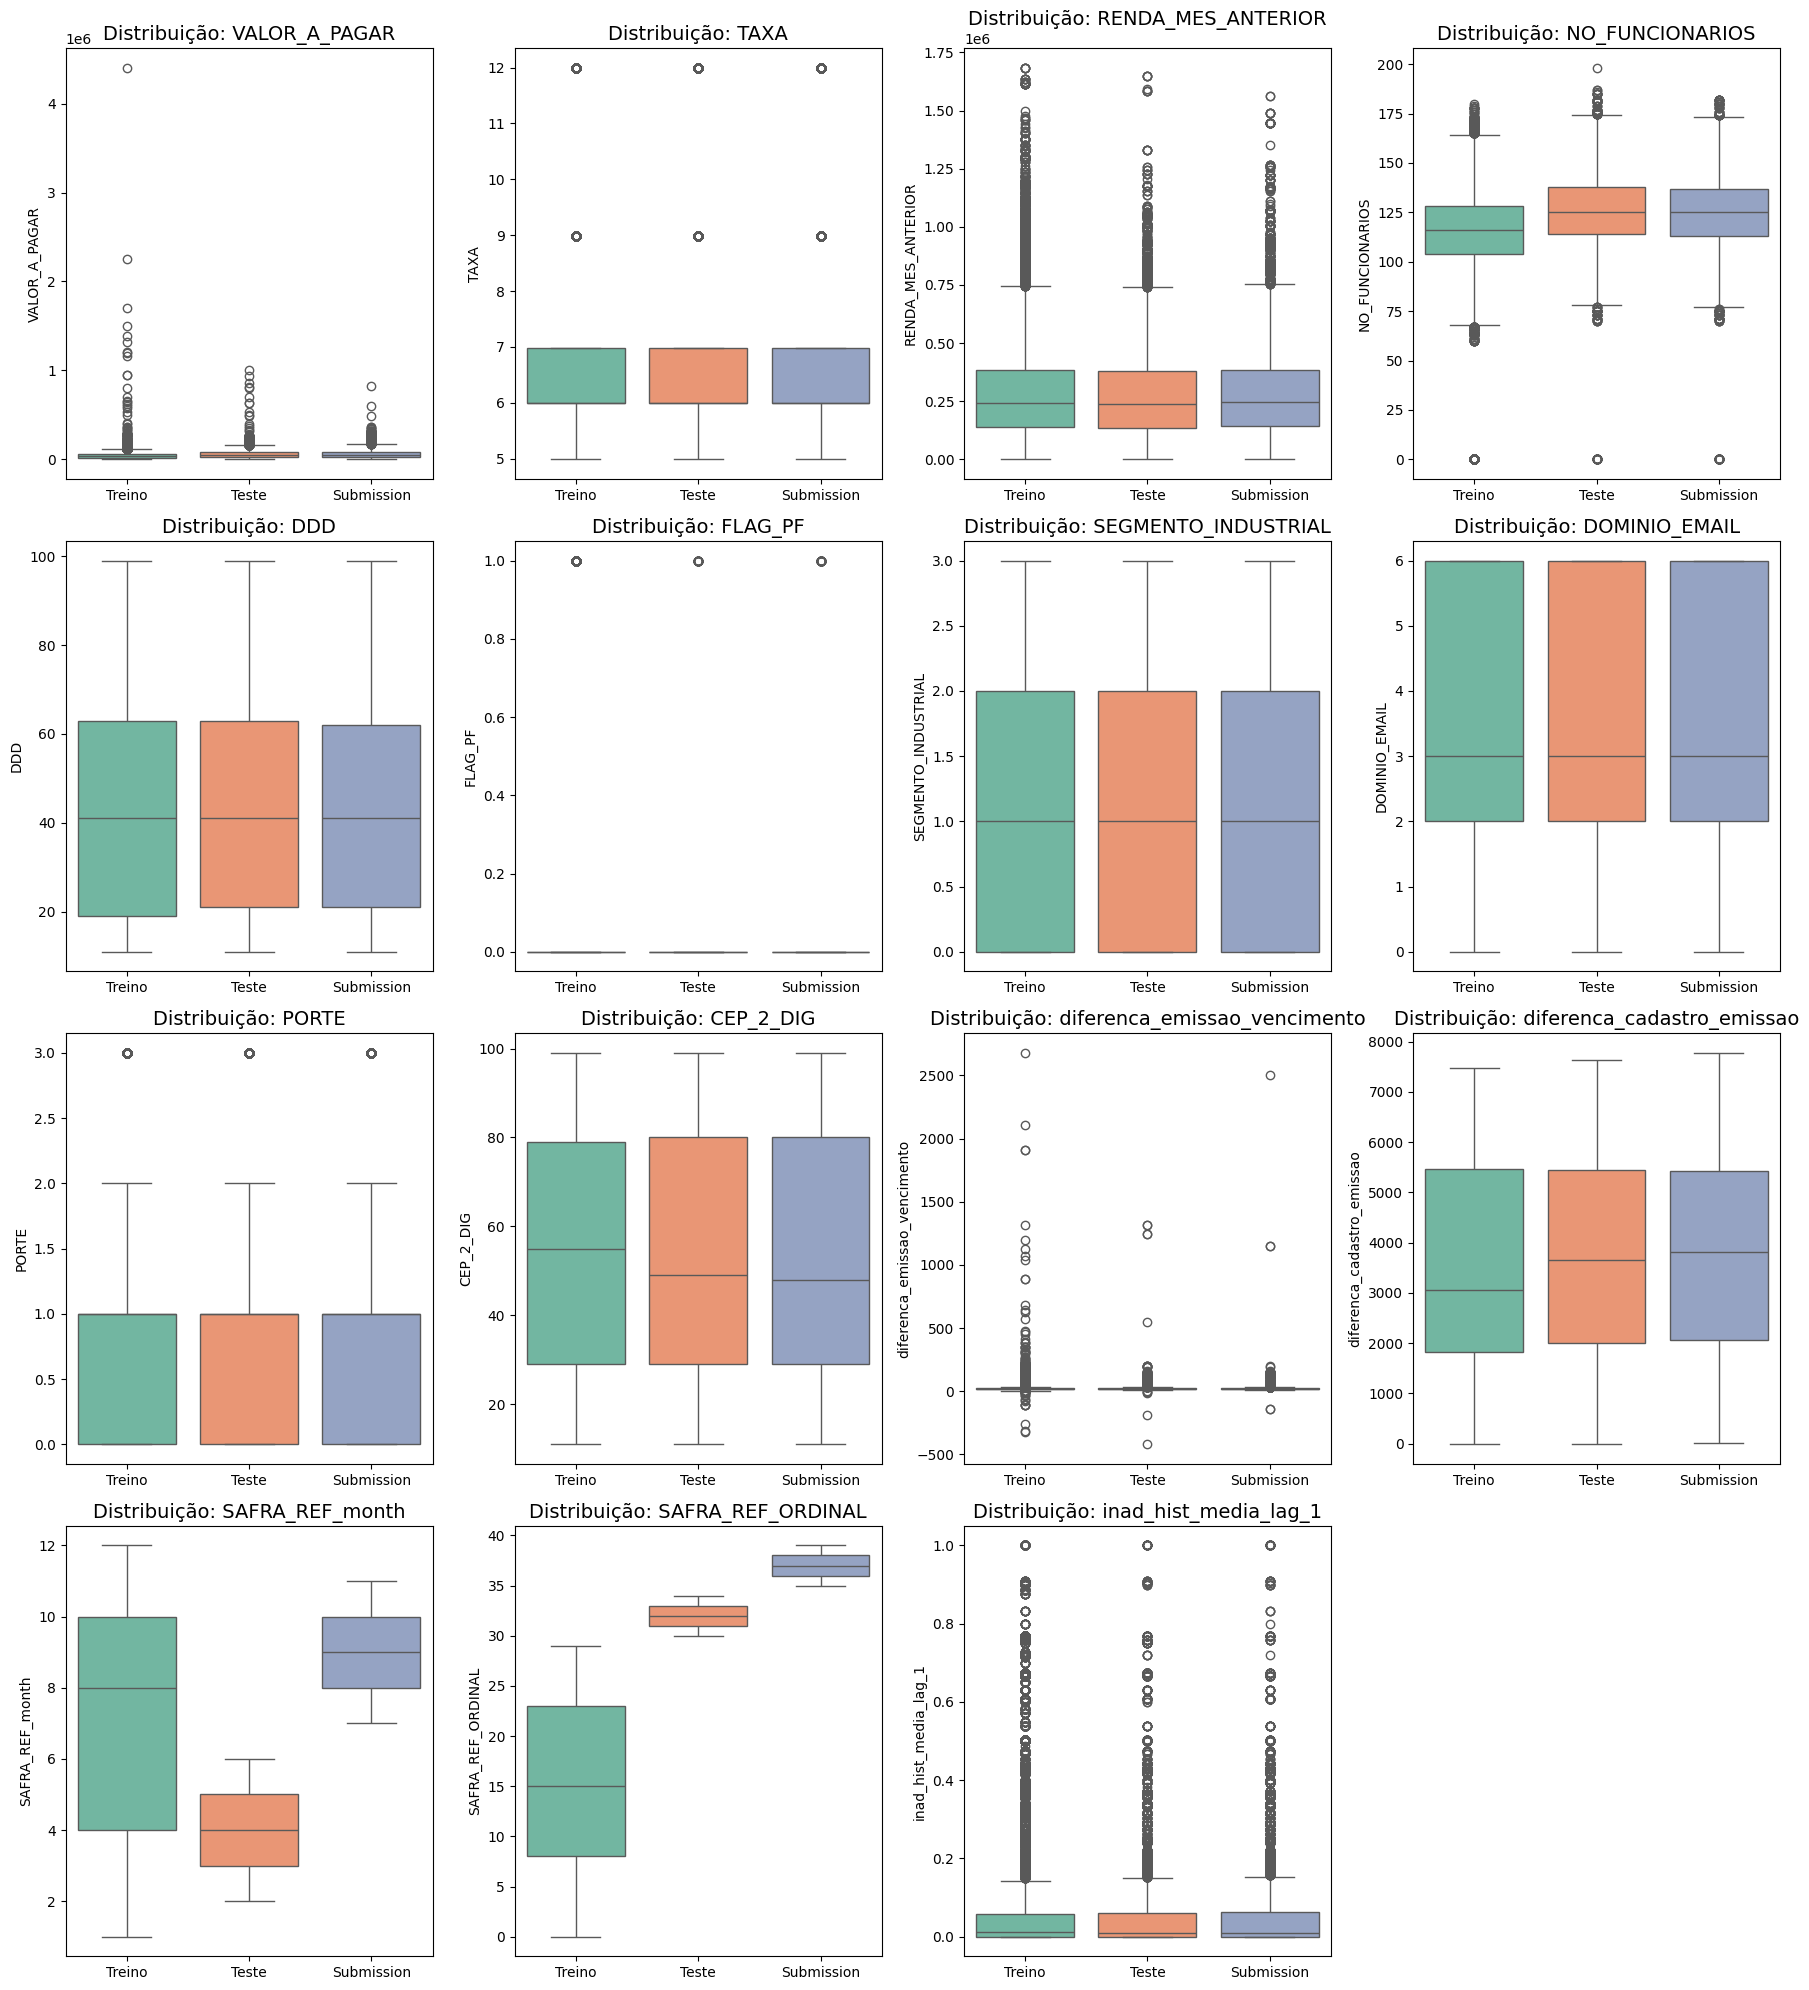

In [364]:
def plot_grid_numerica(train, test, sub):
    cols_num = train.select_dtypes(include=['number']).columns.tolist()
    ignored = ['INADIMPLENTE']
    cols_to_plot = [c for c in cols_num if c not in ignored]
    
    n_cols = 4
    n_rows = math.ceil(len(cols_to_plot) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = axes.flatten() # Transforma a matriz em lista para iterar fácil

    for i, col in enumerate(cols_to_plot):
        df_comp = pd.concat([
            train[[col]].assign(Base='Treino'),
            test[[col]].assign(Base='Teste'),
            sub[[col]].assign(Base='Submission')
        ]).dropna()
        
        sns.boxplot(ax=axes[i], x='Base', y=col, data=df_comp, palette='Set2', hue='Base', legend=False)
        axes[i].set_title(f'Distribuição: {col}', fontsize=14)
        axes[i].set_xlabel('')
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_grid_numerica(train_, test_, submission)

### Evolução Temporal da Taxa de Inadimplência
- **Agregação:** Cálculo da média da variável alvo (`INADIMPLENTE`) agrupada por safra para os conjuntos de treino e teste, utilizando `.groupby().mean()`.
- **Visualização:** Construção de um gráfico de linhas contínuas (`sns.lineplot`) para monitorar a tendência do comportamento de pagamento ao longo do tempo.
- **Demarcação (OOT):** Inserção de uma linha vertical de corte (`plt.axvline`) para ilustrar claramente a fronteira cronológica entre o aprendizado e a validação out-of-time.

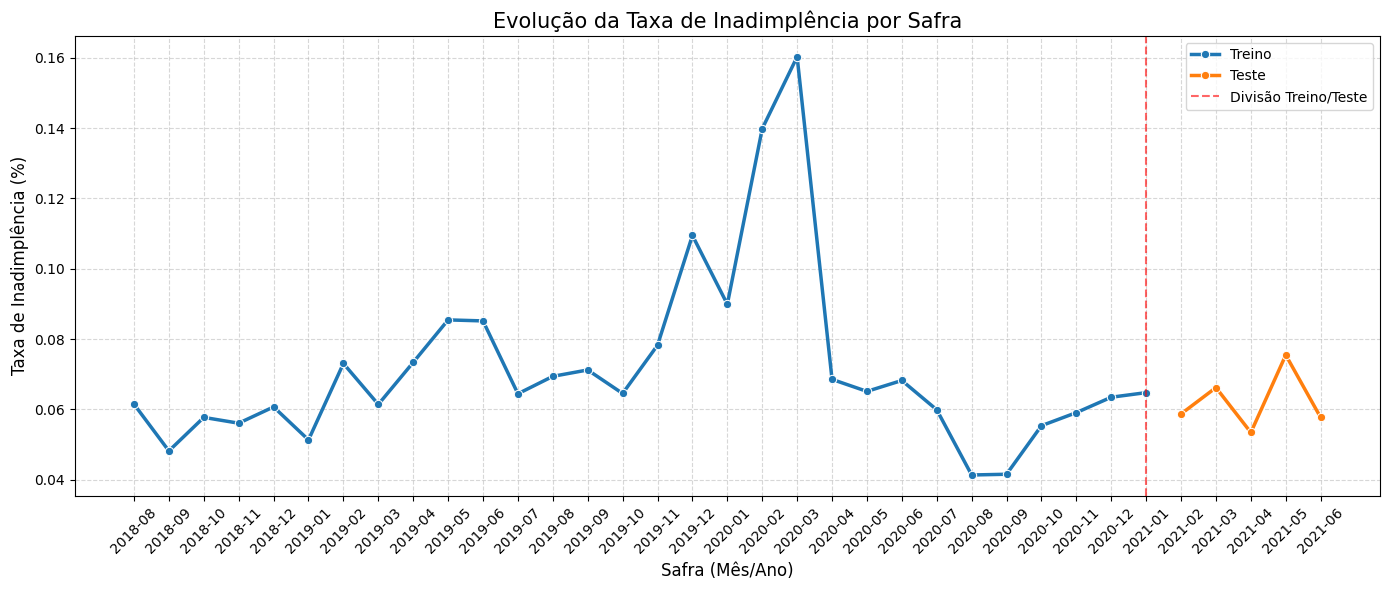

In [365]:
def plot_evolucao_inadimplencia(train, test, col_safra='SAFRA_REF', col_target='INADIMPLENTE'):
    evol_train = train.groupby(col_safra)[col_target].mean().reset_index()
    evol_train['Base'] = 'Treino'
    
    evol_test = test.groupby(col_safra)[col_target].mean().reset_index()
    evol_test['Base'] = 'Teste'
    
    evol_total = pd.concat([evol_train, evol_test])
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=evol_total, x=col_safra, y=col_target, hue='Base', marker='o', linewidth=2.5)
    
    plt.axvline(x=evol_train[col_safra].iloc[-1], color='red', linestyle='--', alpha=0.6, label='Divisão Treino/Teste')
    
    plt.title('Evolução da Taxa de Inadimplência por Safra', fontsize=15)
    plt.ylabel('Taxa de Inadimplência (%)', fontsize=12)
    plt.xlabel('Safra (Mês/Ano)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_evolucao_inadimplencia(train, test)

### Validação Visual da Média Histórica
- **Aplicação:** Execução da função de plotagem adaptada para monitorar a feature gerada `inad_hist_media` ao longo das safras transformadas (`SAFRA_REF_ORDINAL`).
- **Estabilidade Temporal:** Uso do gráfico de linhas (`sns.lineplot`) para verificar se o comportamento da média histórica se mantém consistente entre as bases de aprendizado e validação.
- **Fronteira OOT:** Destaque visual da linha de corte temporal para garantir a estabilidade da feature e validar sua aderência no cenário futuro (*out-of-time*).

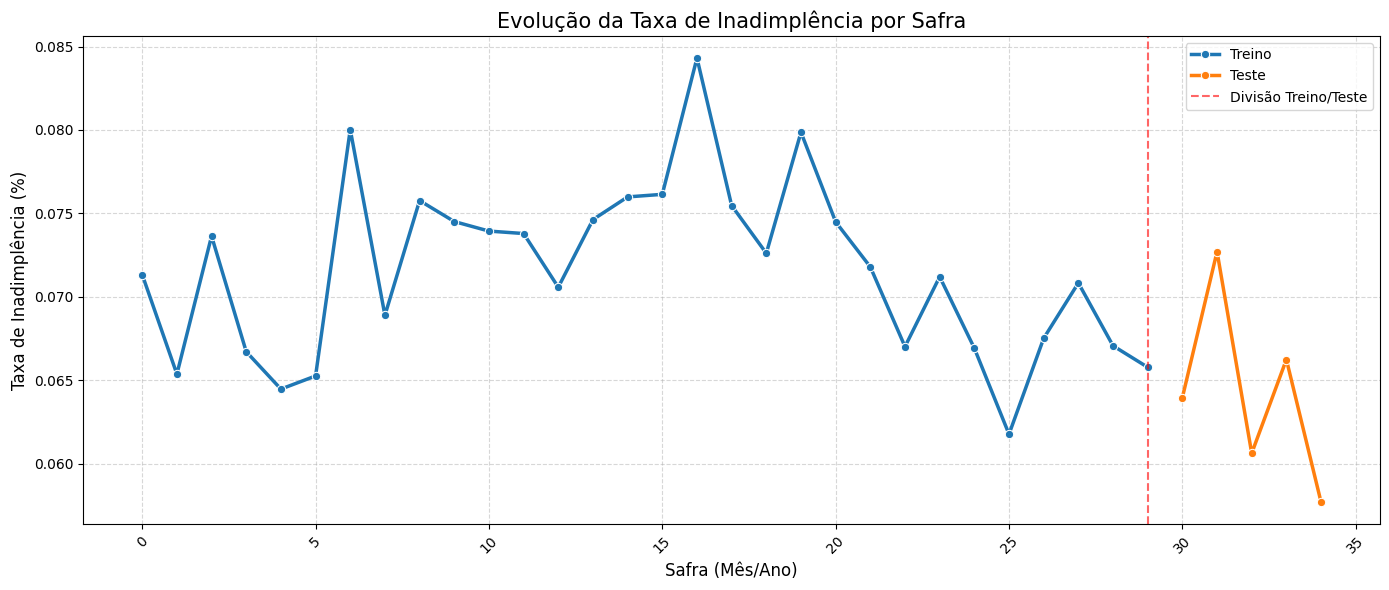

In [366]:
def plot_evolucao_inadimplencia(train, test, col_safra='SAFRA_REF', col_target='INADIMPLENTE'):
    evol_train = train.groupby(col_safra)[col_target].mean().reset_index()
    evol_train['Base'] = 'Treino'
    
    evol_test = test.groupby(col_safra)[col_target].mean().reset_index()
    evol_test['Base'] = 'Teste'
    
    evol_total = pd.concat([evol_train, evol_test])
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=evol_total, x=col_safra, y=col_target, hue='Base', marker='o', linewidth=2.5)
    
    plt.axvline(x=evol_train[col_safra].iloc[-1], color='red', linestyle='--', alpha=0.6, label='Divisão Treino/Teste')
    
    plt.title('Evolução da Taxa de Inadimplência por Safra', fontsize=15)
    plt.ylabel('Taxa de Inadimplência (%)', fontsize=12)
    plt.xlabel('Safra (Mês/Ano)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_evolucao_inadimplencia(train_, test_, col_safra='SAFRA_REF_ORDINAL', col_target='inad_hist_media_lag_1')

### Análise de Relações Multivariadas (Pairplot)
- **Visualização Cruzada:** Geração de uma matriz de dispersão (*scatter plots*) para identificar correlações visuais e separabilidade entre adimplentes e inadimplentes, utilizando a configuração `corner=True` para evitar redundância de gráficos espelhados.


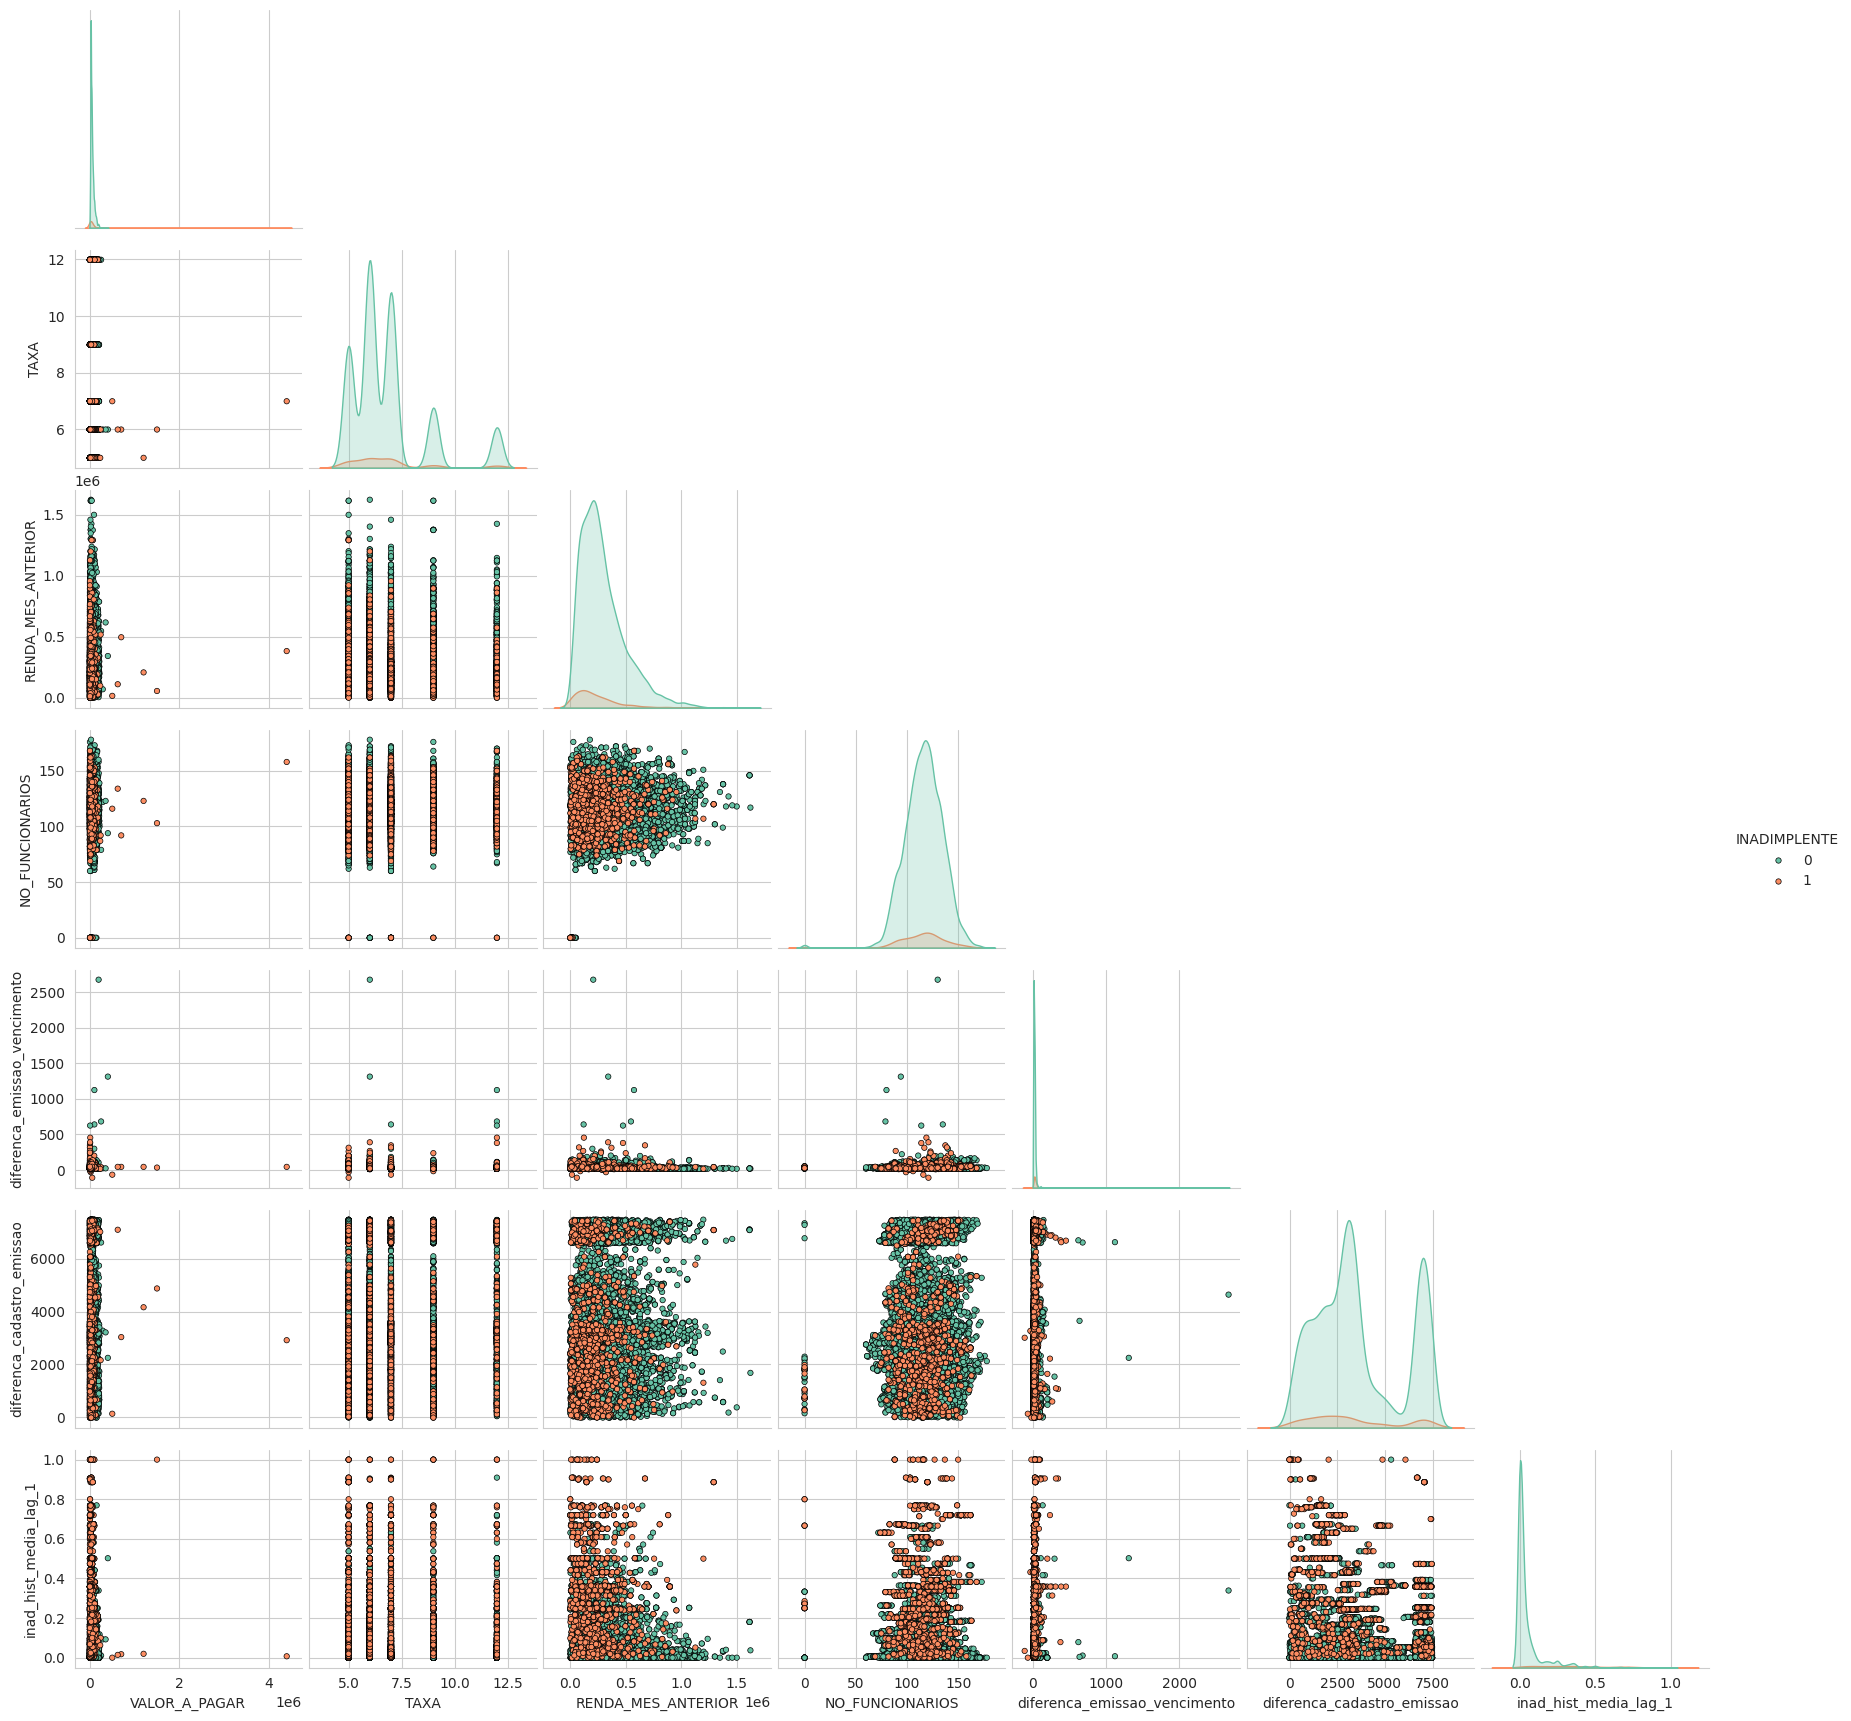

In [405]:
colunas_selecionadas = ['VALOR_A_PAGAR', 'INADIMPLENTE', 'TAXA','RENDA_MES_ANTERIOR','NO_FUNCIONARIOS',  'diferenca_emissao_vencimento','diferenca_cadastro_emissao','inad_hist_media_lag_1']

sns.set_style("whitegrid") 

sns.pairplot(
    data=train_[colunas_selecionadas].sample(n=15000, random_state=42).sort_values('INADIMPLENTE'), 
    hue='INADIMPLENTE',                                  
    palette="Set2",
    diag_kind='kde', 
    corner=True,
    plot_kws={'alpha': 1, 's': 15, 'edgecolor': 'black', 'linewidth': 0.5 }
)

plt.show()

### Visualização de Densidade (KDE) por Classe
- **Estruturação:** Criação de um *grid* dinâmico de *subplots* dimensionado automaticamente com base na quantidade de variáveis numéricas, excluindo colunas de identificação e a própria variável alvo.
- **Análise de Distribuição:** Utilização do `sns.kdeplot` para traçar as curvas de densidade de cada *feature*, segmentadas pela classe alvo (`hue=target`), permitindo avaliar visualmente o poder discriminativo das variáveis.
- **Renderização:** Limpeza do layout através da remoção de eixos (painéis) não utilizados no final da grade (`fig.delaxes`) e aplicação do `tight_layout` para evitar sobreposição de elementos.

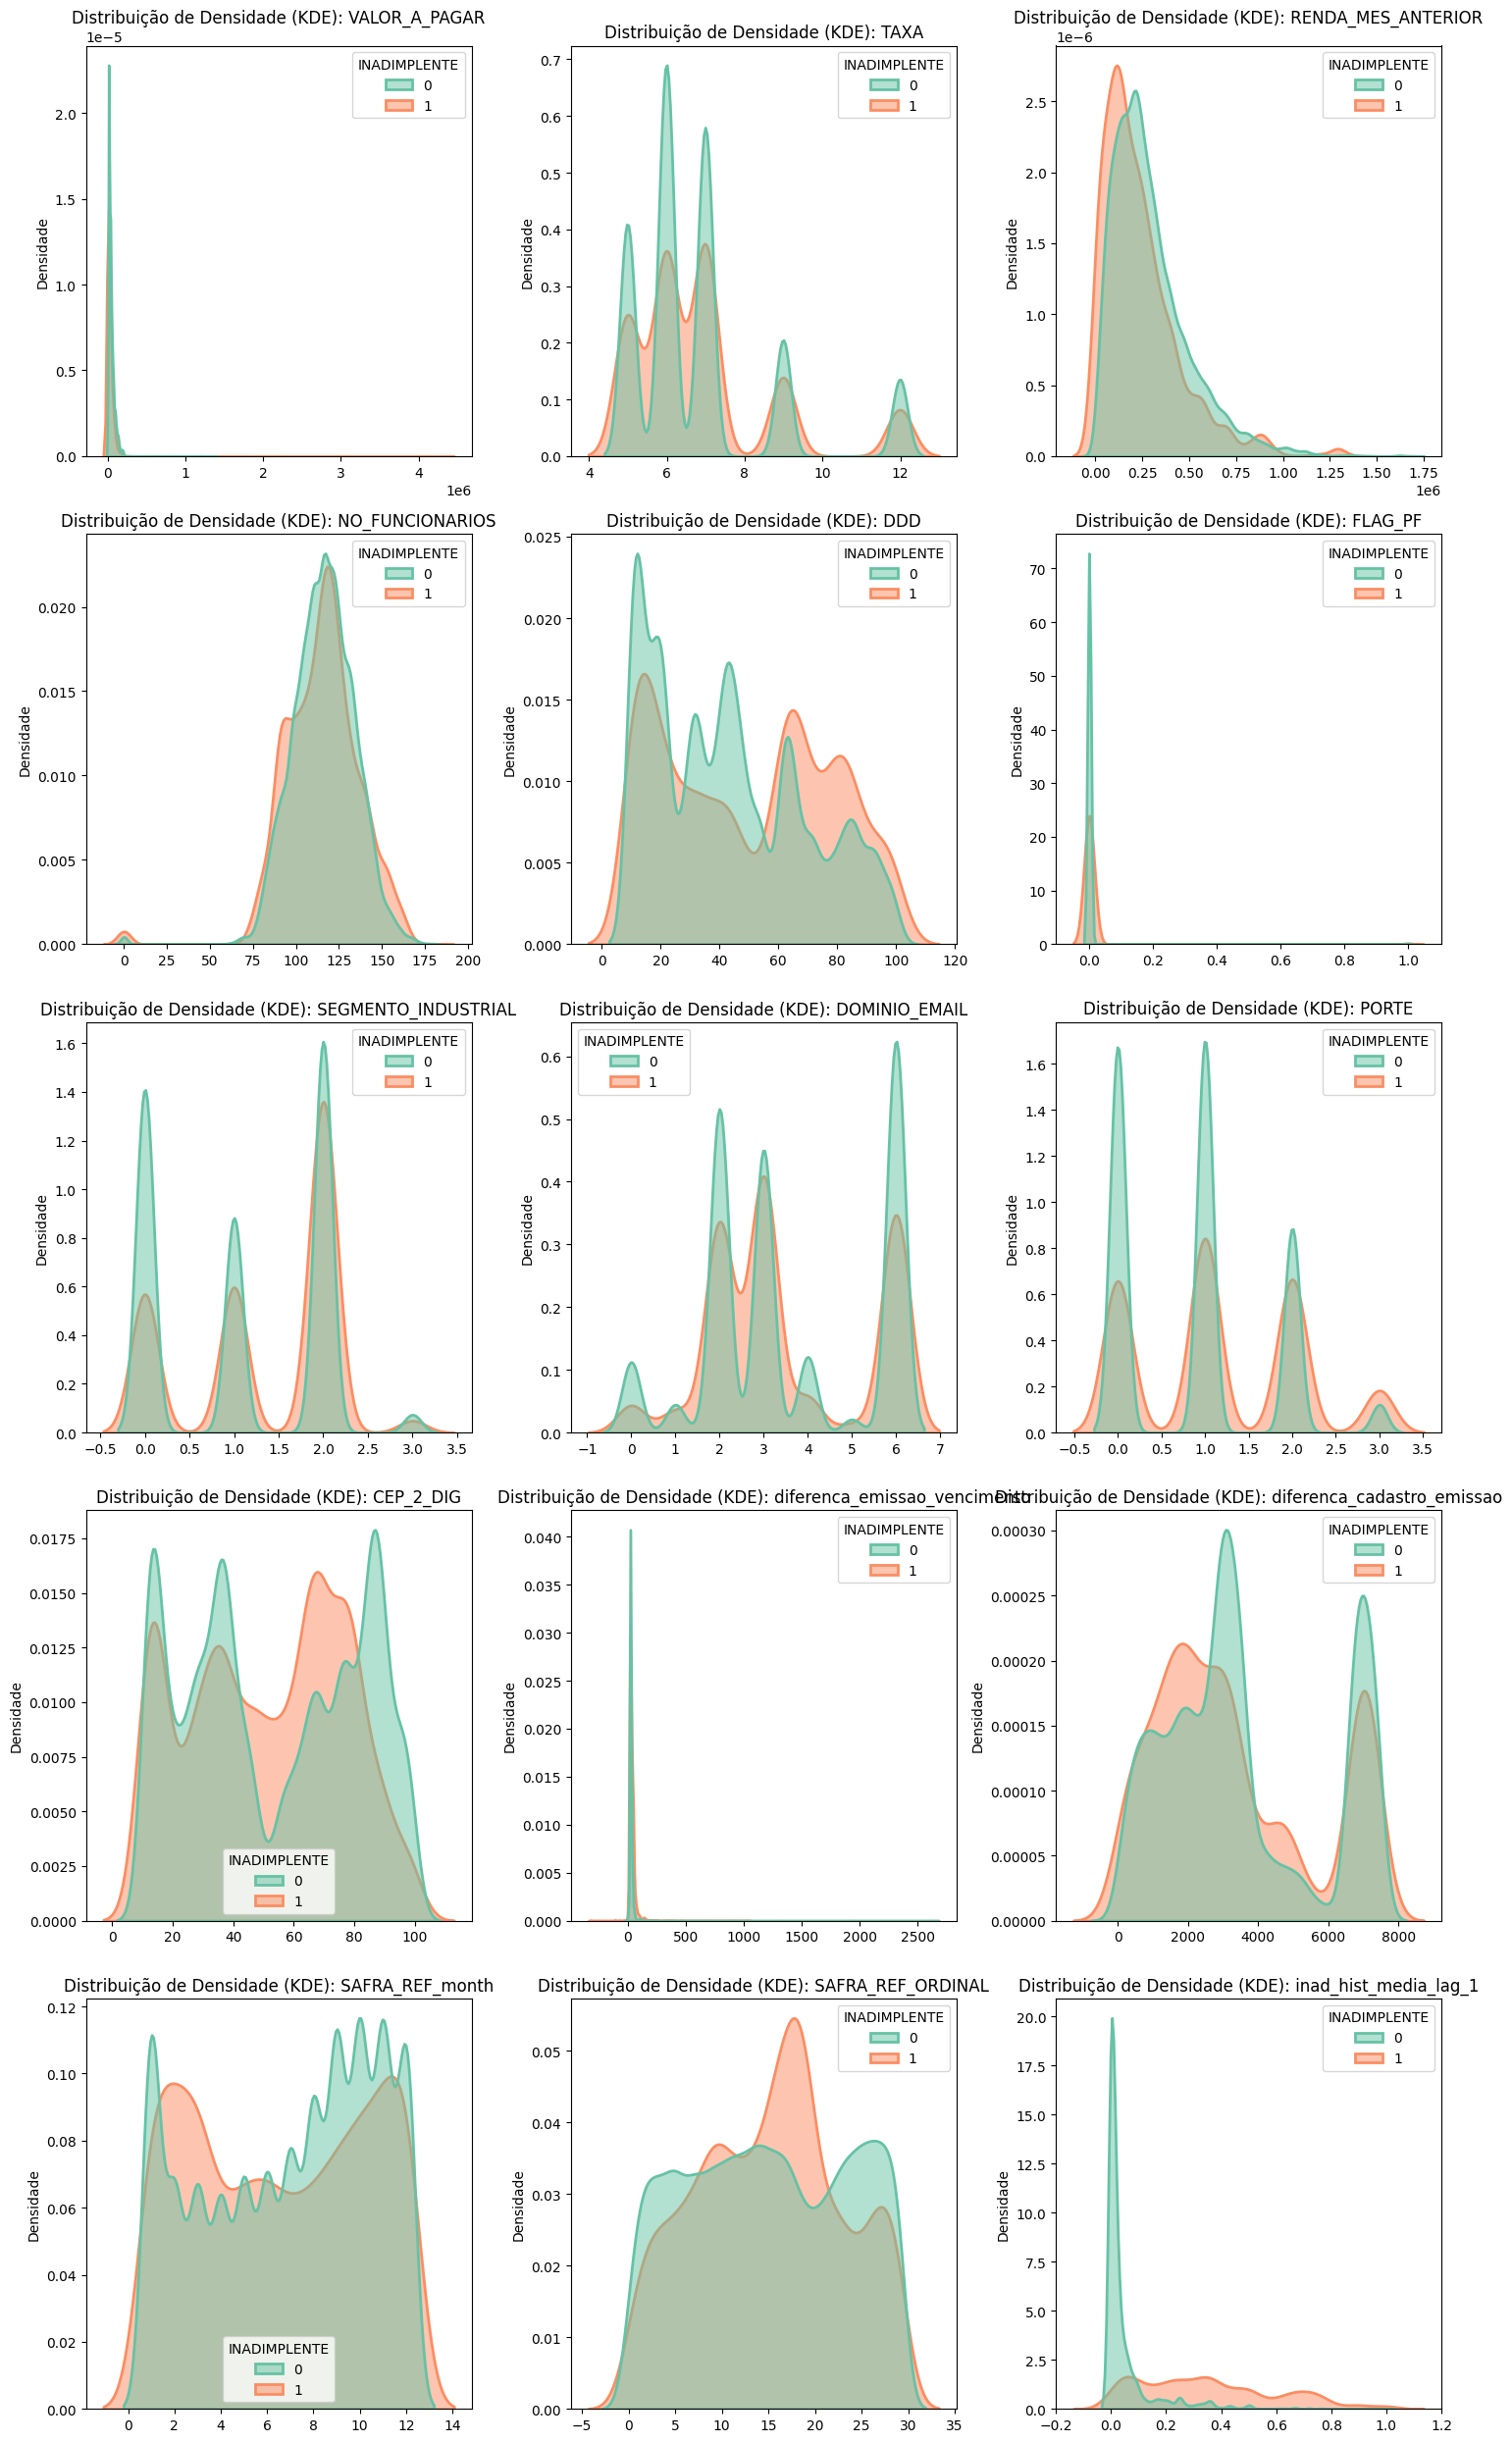

In [367]:
n_cols = 3

cols_num = train_.select_dtypes(include=['number']).columns.tolist()
ignored = ['ID_CLIENTE', 'INADIMPLENTE']
target = "INADIMPLENTE"
cols_to_plot = [c for c in cols_num if c not in ignored]
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if col == target:
        continue

    sns.kdeplot(
        data=train_,
        x=col,
        hue=target,
        fill=True,       
        common_norm=False,
        palette="Set2",
        ax=axes[i],
        alpha=0.5,
        linewidth=2,
        warn_singular=False
    )
    axes[i].set_title(f'Distribuição de Densidade (KDE): {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Densidade')

# Remove eixos extras se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Análise de Correlação de Pearson
- **Cálculo:** Geração da matriz de correlação (`.corr()`) para mensurar a força da relação linear entre todas as variáveis do conjunto de treino.
- **Visualização:** Renderização de um mapa de calor (`sns.heatmap`) com máscara triangular superior para eliminar redundâncias e focar nas associações exclusivas.
- **Interpretação:** Utilização da escala de cores `coolwarm` e anotações numéricas para identificar colinearidade entre features e a força do vínculo com a variável alvo.

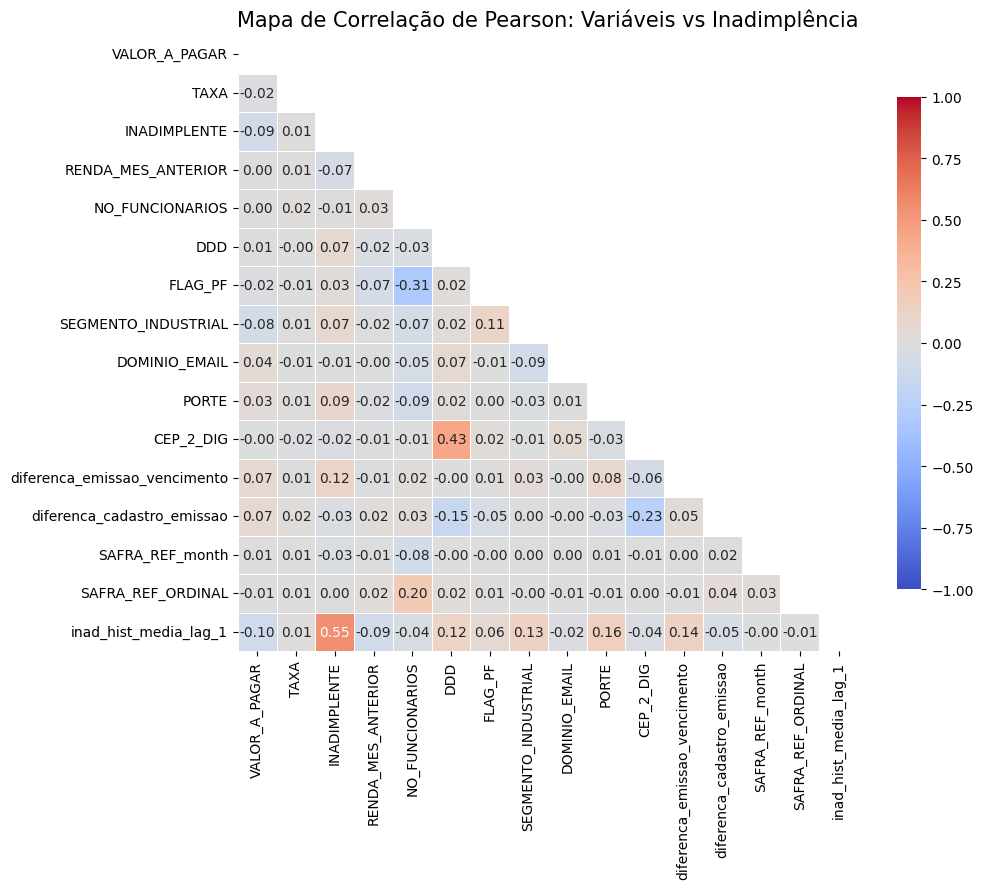

In [368]:
corr_matrix = train_[train_.columns].corr()

plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Gerar o Heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          
    fmt=".2f",           
    cmap='coolwarm',   
    vmin=-1, vmax=1,    
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Mapa de Correlação de Pearson: Variáveis vs Inadimplência', fontsize=15)
plt.show()

## Feature Importance

In [369]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

### Seleção de Atributos com Pesos Multimetodológicos
- **Abordagem Híbrida:** Implementação da função `feature_importance_weighted` que combina Random Forest (interações), Isolation Forest (anomalias) e Mutual Information (dependência estatística).
- **Normalização e Consenso:** Aplicação de `MinMaxScaler` para padronizar as pontuações e cálculo de uma métrica final ponderada para rankear a utilidade de cada variável.
- **Filtragem:** Seleção automática das `top_features` que atingem um limiar de relevância (> 0.1), otimizando o modelo para as variáveis com maior poder preditivo.

In [370]:
X_train = train_.drop(columns=[target])
y_train = train_[target]


def feature_importance_weighted(X: pd.DataFrame, y: pd.Series,
                                  w_rf=5, w_iso=2, w_mi=4,
                                  contamination=0.1, random_state=42):
    """
    Combina 3 métodos de importância de feature com pesos configuráveis.
    
    RF  → captura relações não-lineares e interações entre features
    ISO → penaliza features que isolam anomalias (útil para dados ruidosos)
    MI  → mede dependência estatística com o target (funciona com não-linearidades)
    """
    results = {}

    rf = RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1)
    rf.fit(X, y)
    results["rf"] = rf.feature_importances_

    iso_scores = []
    for col in X.columns:
        iso = IsolationForest(contamination=contamination, random_state=random_state)
        iso.fit(X[[col]])
        # score_samples retorna negativo: inverte para "utilidade"
        score = -iso.score_samples(X[[col]]).mean()
        iso_scores.append(score)
    results["iso"] = np.array(iso_scores)

    results["mi"] = mutual_info_classif(X, y, random_state=random_state)

    scaler = MinMaxScaler()
    norm = {k: scaler.fit_transform(v.reshape(-1, 1)).ravel()
            for k, v in results.items()}

    total_w = w_rf + w_iso + w_mi
    combined = (norm["rf"] * w_rf + norm["iso"] * w_iso + norm["mi"] * w_mi) / total_w

    df_result = pd.DataFrame({
        "feature":   X.columns,
        "rf_score":  norm["rf"].round(3),
        "iso_score": norm["iso"].round(3),
        "mi_score":  norm["mi"].round(3),
        "final":     combined.round(3),
    }).sort_values("final", ascending=False).reset_index(drop=True)

    df_result.index += 1  # ranking começa em 1
    return df_result

df_scores = feature_importance_weighted(X_train, y_train, w_rf=5, w_iso=2, w_mi=4)
print(df_scores)
top_features = df_scores[df_scores["final"]>0.1]["feature"]

                         feature  rf_score  iso_score  mi_score  final
1          inad_hist_media_lag_1     1.000      0.067     0.947  0.811
2                  VALOR_A_PAGAR     0.793      0.320     0.533  0.612
3             RENDA_MES_ANTERIOR     0.265      0.360     1.000  0.550
4     diferenca_cadastro_emissao     0.528      0.645     0.285  0.461
5   diferenca_emissao_vencimento     0.413      0.000     0.380  0.326
6                      CEP_2_DIG     0.133      0.868     0.281  0.320
7                            DDD     0.148      0.889     0.203  0.303
8              SAFRA_REF_ORDINAL     0.212      1.000     0.037  0.291
9                SAFRA_REF_month     0.156      0.983     0.031  0.261
10               NO_FUNCIONARIOS     0.221      0.384     0.075  0.197
11                          TAXA     0.120      0.687     0.022  0.187
12                         PORTE     0.063      0.686     0.076  0.181
13           SEGMENTO_INDUSTRIAL     0.050      0.645     0.097  0.175
14    

### Visualização de Importância das Variáveis
- **Gráfico Comparativo:** Geração de barras horizontais para comparar os scores de Random Forest, Isolation Forest, Mutual Information e a média ponderada final.
- **Customização e Ranking:** Ordenação automática por relevância e filtragem das `top_n` variáveis, facilitando a identificação dos principais preditores de inadimplência.

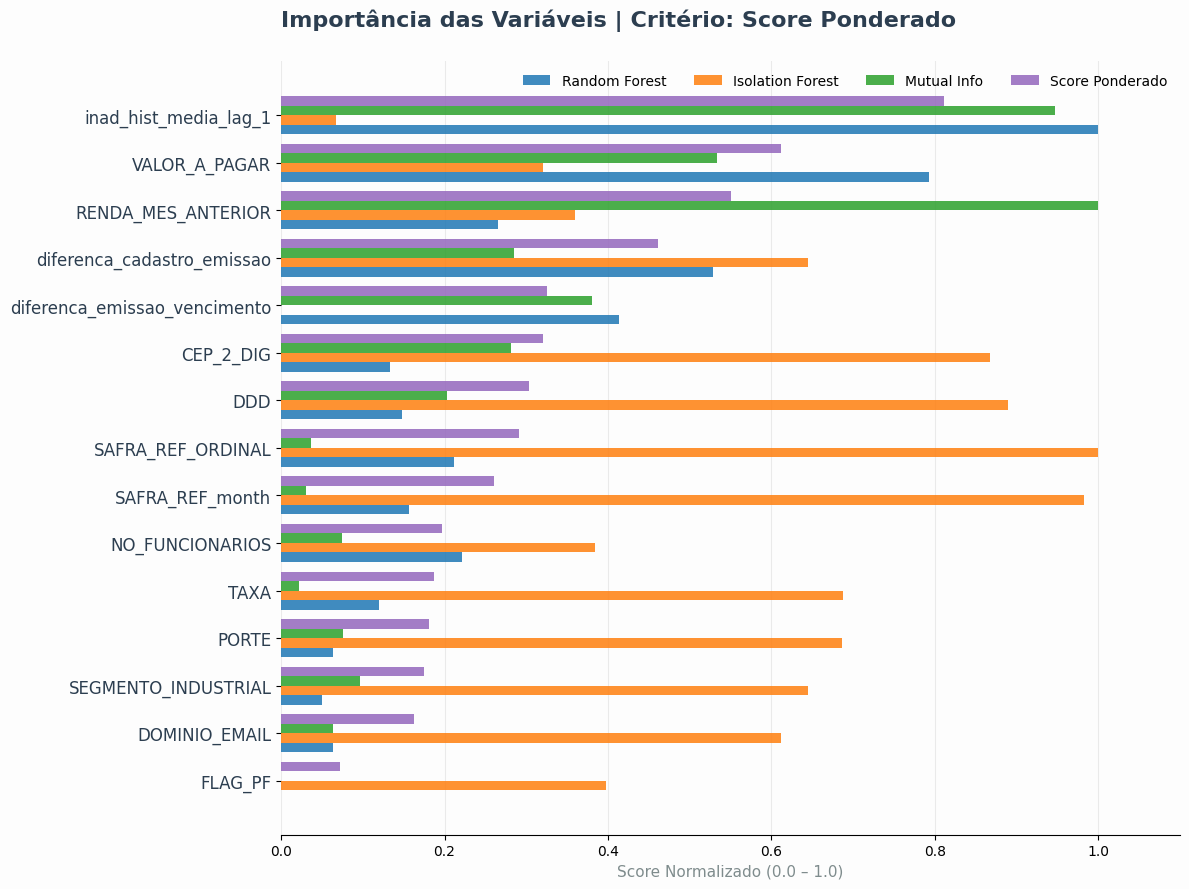

In [371]:
from matplotlib import colormaps

def plot_feature_importance(df: pd.DataFrame,
                             view="all", sort_by="final",
                             top_n: int = None,
                             figsize=(12, 9)) -> None:
    
    cmap = colormaps.get_cmap('tab10') 
    
    col_map = {
        "rf":    ("rf_score",  cmap(0), "Random Forest"),
        "iso":   ("iso_score", cmap(1), "Isolation Forest"),
        "mi":    ("mi_score",  cmap(2), "Mutual Info"),
        "final": ("final",     cmap(4), "Score Ponderado"), 
    }
    
    cols = list(col_map.keys()) if view == "all" else [view]

    # Ordenação e Filtragem
    sort_col = col_map[sort_by][0] if sort_by in col_map else sort_by
    df_plot = df.sort_values(sort_col, ascending=True)

    if top_n:
        df_plot = df_plot.tail(top_n)

    n_feat = len(df_plot)
    n_cols = len(cols)
    bar_h  = 0.8 / n_cols
    y_pos  = np.arange(n_feat)
    offsets = np.linspace(-(n_cols - 1) / 2, (n_cols - 1) / 2, n_cols) * bar_h

    fig, ax = plt.subplots(figsize=figsize, facecolor='#FDFDFD')
    ax.set_facecolor('#FDFDFD')

    for offset, key in zip(offsets, cols):
        col, color, label = col_map[key]
        bars = ax.barh(y_pos + offset, df_plot[col], height=bar_h,
                      color=color, label=label, edgecolor='none', alpha=0.85)
        
        # Adiciona rótulos de valores se estiver vendo apenas uma métrica (ex: final)
        if n_cols == 1:
            for bar in bars:
                width = bar.get_width()
                ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                        f'{width:.2f}', va='center', fontsize=10, fontweight='bold', color=color)

    # Estilização de Eixos e Títulos
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot["feature"], fontsize=12, color='#2C3E50')
    
    ax.set_title(f"Importância das Variáveis | Critério: {col_map[sort_by][2]}", 
                 loc='left', fontsize=16, fontweight='bold', pad=25, color='#2C3E50')
    
    ax.set_xlabel("Score Normalizado (0.0 – 1.0)", fontsize=11, color='#7F8C8D')
    ax.set_xlim(0, 1.1) # Espaço extra para as labels
    
    # Grade e Limpeza
    ax.xaxis.grid(True, linestyle='-', alpha=0.15, color='gray')
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.legend(loc="upper right", frameon=False, fontsize=10, ncol=n_cols)

    plt.tight_layout()
    plt.show()

# Chamada com o mapa de cores nativo aplicado
plot_feature_importance(df_scores, view="all", sort_by="final", top_n=15)

## Modelos

In [372]:
features_selecionadas = top_features.tolist()
features_selecionadas

['inad_hist_media_lag_1',
 'VALOR_A_PAGAR',
 'RENDA_MES_ANTERIOR',
 'diferenca_cadastro_emissao',
 'diferenca_emissao_vencimento',
 'CEP_2_DIG',
 'DDD',
 'SAFRA_REF_ORDINAL',
 'SAFRA_REF_month',
 'NO_FUNCIONARIOS',
 'TAXA',
 'PORTE',
 'SEGMENTO_INDUSTRIAL',
 'DOMINIO_EMAIL']

### Preparação para Modelagem e Seleção de Atributos
- **Configuração:** Supressão de avisos (`warnings`) e importação de um ecossistema completo de algoritmos (XGBoost, Redes Neurais, Random Forest) e métricas de avaliação.
- **Redução de Dimensionalidade:** Aplicação do filtro de seleção para manter apenas as `features_selecionadas` identificadas no ranking de importância, otimizando a performance.
- **Divisão Final:** Estruturação dos conjuntos de dados de treino e teste (`X_train_final`, `y_train_final`, etc.) prontos para o processo de calibração e validação cruzada.

In [373]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

from sklearn.metrics import brier_score_loss, make_scorer, roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.calibration import CalibratedClassifierCV, calibration_curve, clone


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

features_selecionadas = top_features.tolist()

X_train_final = train_[features_selecionadas]
y_train_final = train_[target]

X_test_final = test_[features_selecionadas]
y_test_final = test_[target]

### Benchmarking e Calibração de Modelos Preditivos
- **Configuração de Algoritmos:** Definição de modelos (Logística, RF, GBM e XGBoost) com ajuste de hiperparâmetros e tratamento de desbalanceamento via `class_weight` e `scale_pos_weight`.
- **Validação e Calibração:** Aplicação de `StratifiedKFold` para validação cruzada e `CalibratedClassifierCV` (isotônica) para garantir que as probabilidades preditas reflitam a frequência real dos eventos.
- **Avaliação Multimétrica:** Geração de um dashboard comparativo consolidando métricas de treino (CV) e teste, incluindo AUC, F1-Score e Brier Score para mensurar a qualidade da calibração.

In [374]:
scale = (y_train_final == 0).sum() / (y_train_final == 1).sum()

modelos = {
    "Regressão Logística": LogisticRegression(class_weight="balanced", max_iter=400, random_state=42, tol=0.02),
    "Random Forest":       RandomForestClassifier(class_weight="balanced", n_estimators=222, max_depth=12,min_samples_split=2, min_samples_leaf=7,max_features="log2", n_jobs=-1, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=293, random_state=42, learning_rate= 0.042, max_depth=8, min_samples_split=6, min_samples_leaf=5, subsample=0.67, max_features="log2"),
    "XGBoost":             XGBClassifier(n_estimators=294, learning_rate=0.021, max_depth=8, scale_pos_weight=scale, random_state=42, tree_method="hist", subsample=0.922, reg_lambda= 0.173),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=10),
}

def comparar_modelos(X_train, y_train, X_test, y_test, threshold=0.5):
    X_train = X_train.astype(float)
    X_test  = X_test.astype(float)
    y_train = y_train.astype(int)
    y_test  = y_test.astype(int)

    lista_resultados = []
    probabilidades    = {}
    predictions       = {}
    modelos_treinados = {}

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    brier_scorer = make_scorer(brier_score_loss, response_method='predict_proba', greater_is_better=False)

    for nome, model in modelos.items():
        print(f"Treinando modelo {nome}")
        calibrated_model = CalibratedClassifierCV(estimator=model, method="isotonic", cv=5)
        
        cv_results = cross_validate(
            calibrated_model, X_train, y_train,
            cv=skf,
            scoring={
                'accuracy': 'accuracy',
                'recall': 'recall',
                'precision': 'precision',
                'f1': 'f1',
                'roc_auc': 'roc_auc',
                'brier': brier_scorer 
            },
            n_jobs=-1
        )

        calibrated_model.fit(X_train, y_train)
        y_proba = calibrated_model.predict_proba(X_test)[:, 1]
        
        y_pred = (y_proba >= threshold).astype(int) 

        probabilidades[nome] = y_proba
        predictions[nome]    = y_pred
        modelos_treinados[nome]=calibrated_model

        metricas = {
            "Modelo":          nome,
            "CV Acurácia":     cv_results["test_accuracy"].mean(),
            "CV Recall":       cv_results["test_recall"].mean(),
            "CV Precision":    cv_results["test_precision"].mean(),
            "CV F1":           cv_results["test_f1"].mean(),
            "CV AUC":          cv_results["test_roc_auc"].mean(),
            "Teste Acurácia":  accuracy_score(y_test, y_pred),
            "Teste Recall":    recall_score(y_test, y_pred),
            "Teste Precision": precision_score(y_test, y_pred, zero_division=0),
            "Teste F1":        f1_score(y_test, y_pred),
            "Teste AUC":       roc_auc_score(y_test, y_proba),
            "Brier Score":     brier_score_loss(y_test, y_proba),
        }
        lista_resultados.append(metricas)

    df_resultados = (
        pd.DataFrame(lista_resultados)
        .set_index("Modelo")
        .sort_values(by="Teste AUC", ascending=False))
    
    return df_resultados, probabilidades, predictions, modelos_treinados

resultados_modelos, probabilidades_modelos, predictions_modelos, modelos_treinados = comparar_modelos(X_train_final, y_train_final, X_test_final, y_test_final, threshold=0.30)

display(resultados_modelos)

Treinando modelo Regressão Logística
Treinando modelo Random Forest
Treinando modelo Gradient Boosting
Treinando modelo XGBoost
Treinando modelo Decision Tree


,CV Acurácia,CV Recall,CV Precision,CV F1,CV AUC,Teste Acurácia,Teste Recall,Teste Precision,Teste F1,Teste AUC,Brier Score
Modelo,,,,,,,,,,,
Random Forest,0.949542,0.763951,0.620090,0.684432,0.966554,0.933131,0.702156,0.476234,0.567538,0.922314,0.039892
Gradient Boosting,0.961062,0.637627,0.779813,0.701017,0.970241,0.933131,0.663073,0.474903,0.553431,0.921861,0.041671
XGBoost,0.955752,0.658711,0.705518,0.680700,0.963491,0.930520,0.563342,0.454842,0.503311,0.913043,0.044055
Decision Tree,0.946796,0.355783,0.785489,0.487894,0.949669,0.941974,0.326146,0.561485,0.412617,0.884487,0.045489
Regressão Logística,0.928441,0.005326,0.532222,0.010546,0.772587,0.918056,0.261456,0.313409,0.285084,0.785024,0.054152


### Análise de Curva de Calibração
- **Visualização de Confiabilidade:** Comparação entre as probabilidades previstas pelos modelos e as frequências reais observadas nos dados, utilizando a `calibration_curve`.
- **Diagnóstico de Viés:** A linha tracejada diagonal representa o cenário ideal; desvios acima indicam subestimação do risco, enquanto desvios abaixo sugerem modelos excessivamente pessimistas (superestimação).
- **Validação de Probabilidade:** Essencial para modelos de risco de crédito, garantindo que um score de, por exemplo, 0.30 realmente corresponda a uma taxa de inadimplência de aproximadamente 30% na prática.

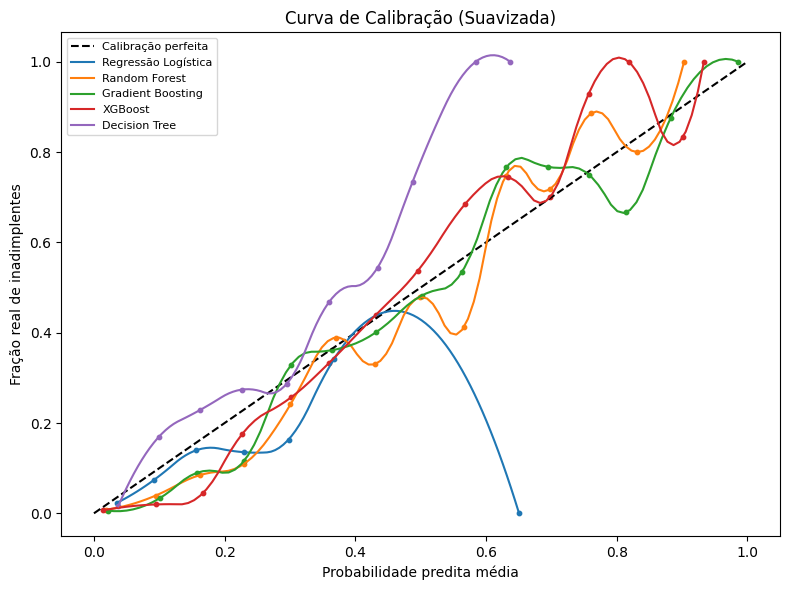

In [375]:
from sklearn.calibration import calibration_curve

from scipy.interpolate import make_interp_spline

def plot_calibracao(y_test, probabilidades):
    _, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Calibração perfeita")

    for nome, y_proba in probabilidades.items():
        frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=15)

        order = np.argsort(mean_pred)
        mean_pred_sorted = mean_pred[order]
        frac_pos_sorted = frac_pos[order]

        x_new = np.linspace(mean_pred_sorted.min(), mean_pred_sorted.max(), 100)

        spline = make_interp_spline(mean_pred_sorted, frac_pos_sorted, k=2)
        y_smooth = spline(x_new)

        ax.plot(x_new, y_smooth, label=nome)
        ax.scatter(mean_pred, frac_pos, s=10)

    ax.set_xlabel("Probabilidade predita média")
    ax.set_ylabel("Fração real de inadimplentes")
    ax.set_title("Curva de Calibração (Suavizada)")
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_calibracao(y_test_final, probabilidades_modelos)

### Matrizes de Confusão e Métricas de Classificação
- **Análise de Erros:** Visualização detalhada de Verdadeiros Positivos, Falsos Negativos e demais quadrantes para cada modelo, permitindo identificar onde o classificador mais falha.
- **Normalização Percentual:** Inclusão de rótulos percentuais em cada célula para facilitar a interpretação do *Recall* (capacidade de capturar inadimplentes) e da *Especificidade* de forma direta.
- **Dashboard Consolidado:** Agrupamento dos resultados em uma grade comparativa, destacando as métricas de Precision, Recall e F1-Score no título de cada gráfico para uma tomada de decisão rápida sobre o melhor modelo.

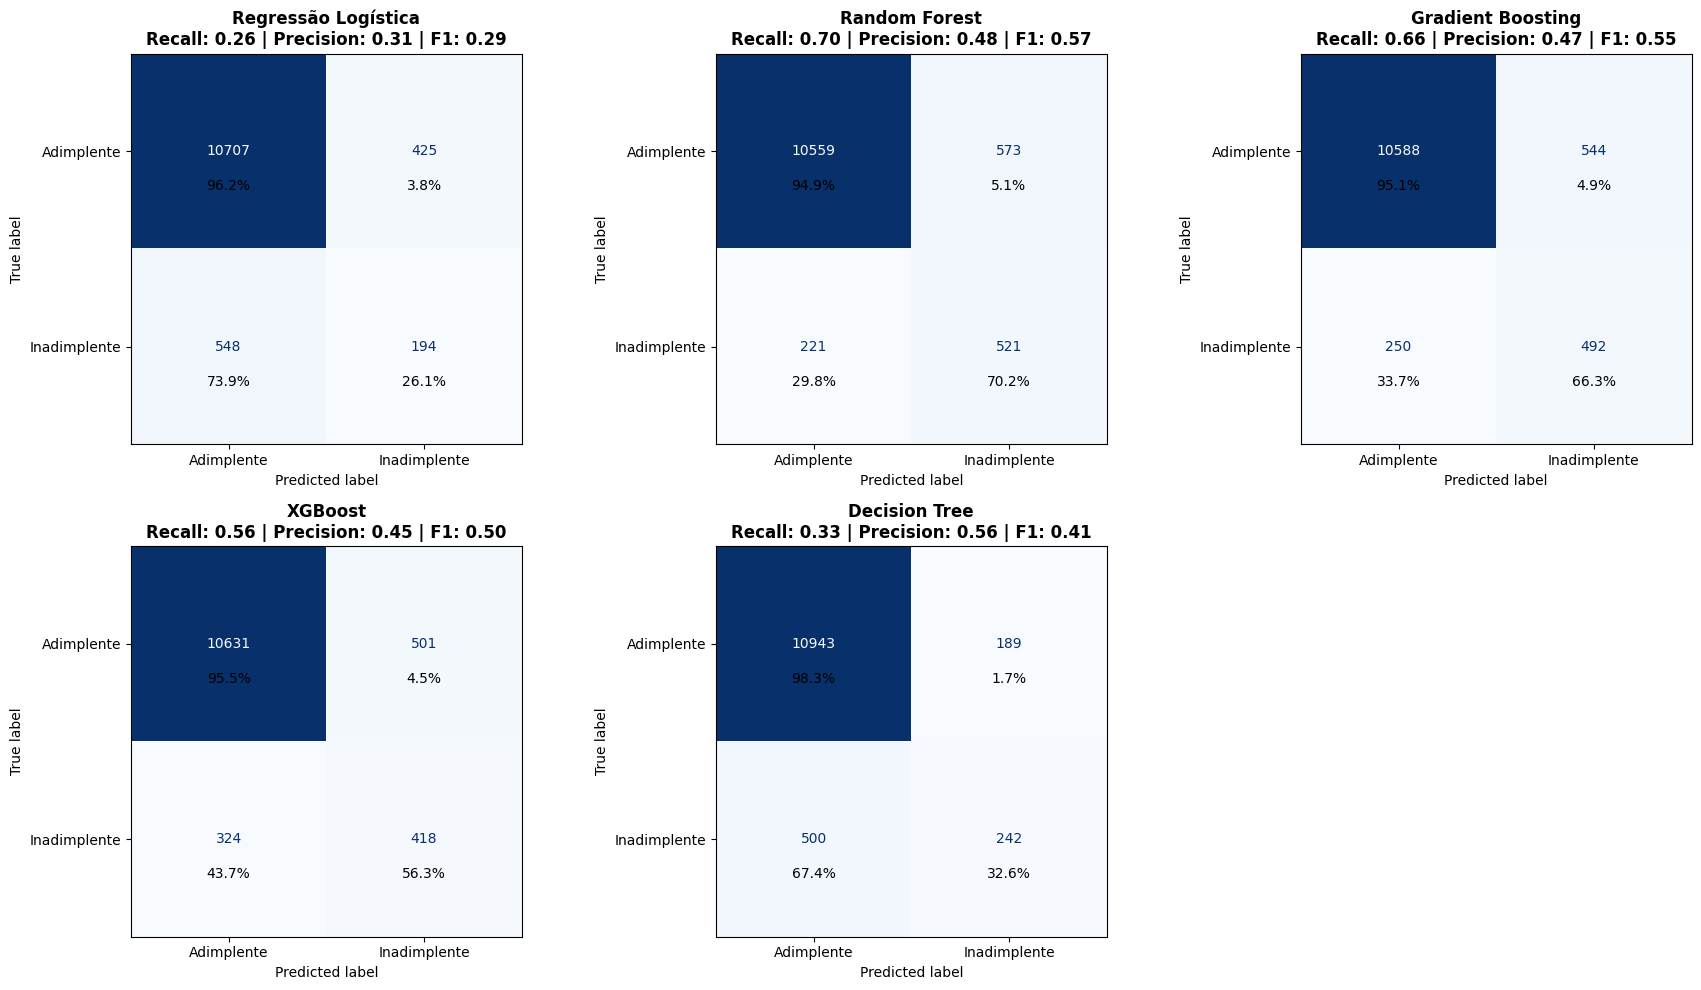

In [376]:
def plot_confusion_matrices(predicoes_modelos, y_test, cols=3, figsize_width=18, figsize_height_per_row=5, cmap='Blues', labels=['Adimplente', 'Inadimplente']):

    n_modelos = len(predicoes_modelos)
    rows = math.ceil(n_modelos / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(figsize_width, rows * figsize_height_per_row))
    axes = axes.flatten()

    for i, (nome, y_pred) in enumerate(predicoes_modelos.items()):
        cm = confusion_matrix(y_test, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=axes[i], cmap=cmap, values_format='d', colorbar=False)

        for j in range(cm.shape[0]):
            for k in range(cm.shape[1]):
                axes[i].text(
                    k, j + 0.2,
                    f"{cm_norm[j, k]:.1%}",
                    ha="center",
                    color="black",
                    fontsize=10
                )

        axes[i].set_title(
            f"{nome}\nRecall: {recall:.2f} | Precision: {precision:.2f} | F1: {f1:.2f}",
            fontsize=12,
            fontweight='bold'
        )

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(predictions_modelos, y_test_final)

### Importância de Atributos do Modelo Final (XGBoost)
- **Extração de Pesos:** Recuperação dos valores de importância diretamente do estimador base do XGBoost contido no objeto calibrado (`calibrated_classifiers_`).
- **Ranking Decrescente:** Organização das variáveis (`features_selecionadas`) por ordem de relevância para o poder preditivo do modelo, permitindo identificar os principais motivadores da inadimplência.
- **Análise Visual:** Utilização do `sns.barplot` para evidenciar quais atributos (como a média histórica ou safras ordinais) possuem maior peso na tomada de decisão do algoritmo.

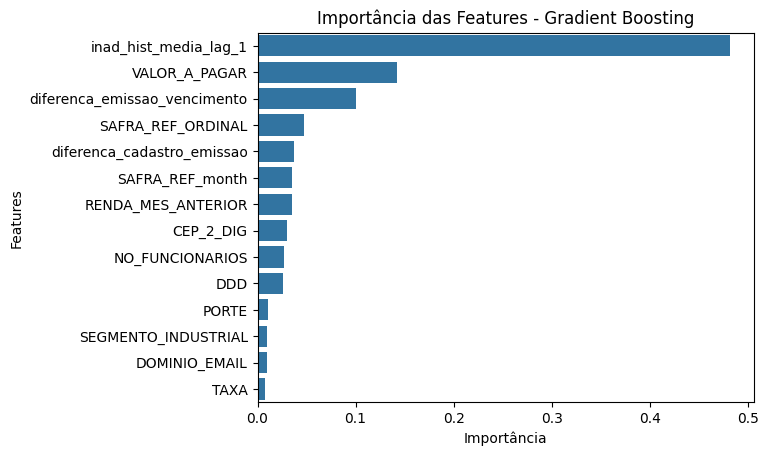

In [383]:
df = pd.DataFrame(data=modelos_treinados["Random Forest"].calibrated_classifiers_[0].estimator.feature_importances_, 
                 index=features_selecionadas, 
                 columns=["Importance"])

df = df.sort_values(by="Importance", ascending=False)

a=sns.barplot(x=df["Importance"], y=df.index)
a.set_title("Importância das Features - Gradient Boosting")
a.set_xlabel("Importância")
a.set_ylabel("Features")
plt.show()

 ## Escolha do modelo, método de tomada de decisão

### Análise de Decisão Multicritério (AHP)
- **Cálculo de Pesos:** Implementa o método da média geométrica para determinar o peso de importância de cada critério na matriz de comparação paritária.
- **Validação de Consistência:** Calcula a Razão de Consistência ($CR$) para garantir que as decisões do especialista não sejam aleatórias ou contraditórias.
- **Conformidade Matemática:** Utiliza o maior autovalor ($\lambda_{max}$) e o Índice Aleatório ($RI$) para validar a robustez lógica das prioridades atribuídas.

In [378]:
def ahp_weights(matrix):
    geom_mean = np.prod(matrix, axis=1)**(1/matrix.shape[0])
    return geom_mean / geom_mean.sum()

def consistency_ratio(matrix):
    eigvals = np.linalg.eigvals(matrix)
    lambda_max = np.max(eigvals.real)
    n = matrix.shape[0]
    CI = (lambda_max - n) / (n - 1)

    RI = {1:0, 2:0, 3:0.58, 4:0.90, 5:1.12, 6:1.24}
    return CI / RI[n]


### Priorização de Critérios e Normalização (AHP)
- **Matriz de Decisão:** Define pesos para as métricas via AHP, priorizando **Recall** e **AUC** como fatores críticos para o negócio (detecção de churn).
- **Validação Lógica:** Calcula a Razão de Consistência ($CR$) para assegurar que as preferências atribuídas na matriz paritária são matematicamente coerentes. (CR<0.1)
- **Normalização de Performance:** Aplica escala *Min-Max* nos resultados dos modelos, preparando as métricas para a decisão final baseada nos pesos calculados.

In [379]:
criteria = ['Acurácia', 'Recall', 'Precision', 'F1', 'AUC']

A = np.array([
    [1,   1/5, 1/3, 1/5, 1/7],  # Acurácia
    [5,   1,   4,   3,   1],    # Recall
    [3,   1/4, 1,   1/3, 1/3],  # Precision
    [5,   1/3, 3,   1,   1/2],  # F1
    [7,   1,   3,   2,   1],    # AUC
])

weights = ahp_weights(A)
CR = consistency_ratio(A)

print(weights, CR)

get_columns=[]
for i in resultados_modelos.columns:
    if(i.startswith("Teste")):
        get_columns.append(i)

df_=resultados_modelos[get_columns]

df_norm = (df_ - df_.min()) / (df_.max() - df_.min())
df_norm

[0.0441298  0.35026288 0.09395667 0.1855034  0.32614725] 0.036530984596495494


,Teste Acurácia,Teste Recall,Teste Precision,Teste F1,Teste AUC
Modelo,,,,,
Random Forest,0.630282,1.000000,0.656352,1.000000,1.000000
Gradient Boosting,0.630282,0.911315,0.650989,0.950054,0.996703
XGBoost,0.521127,0.685015,0.570121,0.772611,0.932473
Decision Tree,1.000000,0.146789,1.000000,0.451517,0.724472
Regressão Logística,0.000000,0.000000,0.000000,0.000000,0.000000


### Ranking Final via Decisão Multicritério (AHP)
- **Cálculo do Score:** Realiza a multiplicação matricial entre as métricas normalizadas e os pesos derivados do AHP para gerar uma pontuação única por modelo.
- **Seleção do Campeão:** Ordena os modelos pelo `Score_AHP`, que reflete o melhor equilíbrio entre os objetivos de negócio (ex: priorização de Recall vs. Precisão).
- **Decisão Final:** Consolida o processo de escolha do algoritmo ideal, baseando-se em evidências estatísticas e prioridades estratégicas pré-definidas.

In [380]:
final_scores = df_norm.values @ weights
df_['Score_AHP'] = final_scores

df_=df_.sort_values('Score_AHP', ascending=False)
df_


,Teste Acurácia,Teste Recall,Teste Precision,Teste F1,Teste AUC,Score_AHP
Modelo,,,,,,
Random Forest,0.933131,0.702156,0.476234,0.567538,0.922314,0.951396
Gradient Boosting,0.933131,0.663073,0.474903,0.553431,0.921861,0.909489
XGBoost,0.930520,0.563342,0.454842,0.503311,0.913043,0.763945
Decision Tree,0.941974,0.326146,0.561485,0.412617,0.884487,0.509544
Regressão Logística,0.918056,0.261456,0.313409,0.285084,0.785024,0.000000


### Finalização e Geração de Submissão
- **Seleção do Campeão:** Identificação automática do melhor algoritmo com base no ranking de performance extraído do dataframe de resultados.
- **Retreinamento Integral:** Consolidação das bases de treino e teste (`X_full` e `y_full`) para treinar o modelo final com o máximo de informação disponível, mantendo a calibração isotônica para precisão probabilística.
- **Predição e Exportação:** Aplicação do modelo final sobre a base de submissão, utilizando as variáveis selecionadas, e exportação dos resultados (ID, Safra e Probabilidade) para o arquivo `submissao_case.csv`.
- **Conformidade de Saída:** Arredondamento das probabilidades para seis casas decimais, garantindo um formato padronizado e limpo para a entrega final do desafio.

In [381]:
melhor_nome = df_.index.tolist()[0]
print(f"Melhor modelo: {melhor_nome}")

X_full = pd.concat([X_train_final, X_test_final], axis=0)
y_full = pd.concat([y_train_final, y_test_final], axis=0)

X_full = X_full.astype(float)
y_full = y_full.astype(int)


estimador_base = modelos[melhor_nome]

modelo_final = CalibratedClassifierCV(estimator=estimador_base, method="isotonic", cv=5)

modelo_final.fit(X_full, y_full)
print("Retreinamento concluído.")

prob_inadimplencia = modelo_final.predict_proba(submission[top_features])[:, 1]

submissao = (
    submission
    .index
    .to_frame(index=False)[["ID_CLIENTE", "SAFRA_REF"]]
    .assign(PROBABILIDADE_INADIMPLENCIA=prob_inadimplencia.round(6))
)

submissao.to_csv("submissao_case.csv", index=False)
display(submissao.head(10))

Melhor modelo: Random Forest
Retreinamento concluído.


,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07,0.008519
1,274692171162531764,2021-07,0.017153
2,274692171162531764,2021-07,0.017153
3,274692171162531764,2021-07,0.018504
4,465309249432033993,2021-07,0.006612
5,465309249432033993,2021-07,0.006612
6,465309249432033993,2021-07,0.007462
7,465309249432033993,2021-07,0.007462
8,5883155883105348987,2021-07,0.013205
9,5883155883105348987,2021-07,0.015655


## Otimização do modelo

In [382]:
import sys
sys.exit("Execução interrompida - Não realizar Otimização")

SystemExit: Execução interrompida - Não realizar Otimização

/home/cleyton-nobre/code/datarisk-case-ds-junior/.venv/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Otimização e Validação
- **Automação:** Importa o `Optuna` para realizar a busca automatizada (*Hyperparameter Tuning*) dos melhores parâmetros.
- **Robustez:** Carrega o `cross_val_score` para validar o desempenho do modelo através de múltiplas dobras de dados (cross-validation).
- **Performance:** Prepara o ambiente para encontrar a configuração ideal que maximize as métricas de negócio com eficiência computacional.

In [ ]:
import optuna
from optuna.samplers import TPESampler
from concurrent.futures import ThreadPoolExecutor


/home/cleyton-nobre/code/datarisk-case-ds-junior/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Otimização de Hiperparâmetros com Optuna
- **Busca Inteligente:** Define um espaço de busca para o `RandomForestClassifier` e `XGBClassifier`, explorando intervalos otimizados para estimadores, taxa de aprendizado e profundidade das árvores.
- **Validação Robusta:** Implementa Validação Cruzada ($k=5$) dentro do loop de otimização para garantir que os parâmetros escolhidos sejam generalistas.
- **Maximização de Recall:** Foca o estudo na métrica de *Recall*, visando capturar o maior número possível de casos de *Inadiplêntes* através de 100 tentativas ($trials$) simultâneas.

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Função auxiliar: Brier Score com CV ──────────────────────────────────────
def _brier_with_cv(pipe, X, y, cv=3):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    briers = []

    X_arr = X.values if hasattr(X, "values") else X
    y_arr = y.values if hasattr(y, "values") else y

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
        y_tr, y_val = y_arr[train_idx], y_arr[val_idx]

        pipe_clone = clone(pipe)
        pipe_clone.fit(X_tr, y_tr)

        y_proba = pipe_clone.predict_proba(X_val)[:, 1]
        briers.append(brier_score_loss(y_val, y_proba))

    return np.mean(briers)


# ── Early stopping callback ───────────────────────────────────────────────────
def make_early_stopping(patience=10):
    def callback(study, trial):
        print(
            f"[{study.study_name}] Trial {trial.number:>3} | "
            f"Brier: {trial.value:.4f} | "
            f"Melhor: {study.best_value:.4f} | "
            f"Params: {trial.params}"
        )
        if trial.number >= patience:
            recent_values = [
                study.trials[i].value
                for i in range(trial.number - patience, trial.number)
                if study.trials[i].value is not None
            ]
            if study.best_value not in recent_values:
                print(f"[{study.study_name}] Early stopping acionado no trial {trial.number}.")
                study.stop()
    return callback

# ── Objectives ────────────────────────────────────────────────────────────────
def objective_rf(trial):
    model = RandomForestClassifier(
        n_estimators      = trial.suggest_int("n_estimators", 100, 300),
        max_depth         = trial.suggest_int("max_depth", 3, 12),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        class_weight      = "balanced",
        n_jobs            = -1,
        random_state      = 42,
    )
    calibrated = CalibratedClassifierCV(model, method="isotonic", cv=3)
    pipe = Pipeline([("model", calibrated)])
    return _brier_with_cv(pipe, X_train_final, y_train_final)


def objective_xgb(trial):
    scale = (y_train_final == 0).sum() / (y_train_final == 1).sum()
    model = XGBClassifier(
        n_estimators     = trial.suggest_int("n_estimators", 100, 300),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth        = trial.suggest_int("max_depth", 3, 8),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        scale_pos_weight = scale,
        random_state     = 42,
        tree_method      = "hist",
        device           = "cpu",
        n_jobs           = -1,
    )
    calibrated = CalibratedClassifierCV(model, method="isotonic", cv=3)  # corrigido: era 5
    pipe = Pipeline([("model", calibrated)])
    return _brier_with_cv(pipe, X_train_final, y_train_final)


def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators      = trial.suggest_int("n_estimators", 100, 300),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int("max_depth", 3, 8),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        random_state      = 42,
    )
    calibrated = CalibratedClassifierCV(model, method="isotonic", cv=3)  # corrigido: era 5
    pipe = Pipeline([("model", calibrated)])
    return _brier_with_cv(pipe, X_train_final, y_train_final)


# ── Rodar estudos em paralelo ─────────────────────────────────────────────────
def run_study(name, objective):
    study = optuna.create_study(direction  = "minimize", study_name = name,  sampler    = TPESampler(seed=42),)

    study.optimize(objective, n_trials  = 30, n_jobs    = 2, callbacks = [make_early_stopping(patience=10)],)
    return study

configs = [
    ("RF_brier",  objective_rf),
    ("GB_brier",  objective_gb),
    ("XGB_brier", objective_xgb),
]

with ThreadPoolExecutor(max_workers=3) as executor:
    futures = {executor.submit(run_study, name, obj): name for name, obj in configs}
    results = {name: future.result() for future, name in 
               zip(futures.keys(), futures.values())}

study_rf  = results["RF_brier"]
study_gb  = results["GB_brier"]
study_xgb = results["XGB_brier"]

# ── Resultados ────────────────────────────────────────────────────────────────
for name, study in [("Random Forest", study_rf), ("Gradient Boosting", study_gb), ("XGBoost", study_xgb)]:
    print(f"\n=== {name} ===")
    print(f"Melhor Brier Score : {study.best_value:.4f}")
    print(f"Trials rodados     : {len(study.trials)}")
    print(f"Parâmetros         : {study.best_params}")

[RF_brier] Trial   1 | Brier: 0.0473 | Melhor: 0.0473 | Params: {'n_estimators': 189, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
[RF_brier] Trial   0 | Brier: 0.0385 | Melhor: 0.0385 | Params: {'n_estimators': 200, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
[XGB_brier] Trial   1 | Brier: 0.0371 | Melhor: 0.0371 | Params: {'n_estimators': 181, 'learning_rate': 0.018217928193178124, 'max_depth': 6, 'subsample': 0.9966565561373268, 'colsample_bytree': 0.6261914101513223, 'min_child_weight': 9, 'reg_alpha': 0.8418813308315557, 'reg_lambda': 0.0021994642779963464}
[RF_brier] Trial   2 | Brier: 0.0461 | Melhor: 0.0385 | Params: {'n_estimators': 181, 'max_depth': 5, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'log2'}
[XGB_brier] Trial   0 | Brier: 0.0348 | Melhor: 0.0348 | Params: {'n_estimators': 294, 'learning_rate': 0.010888083268603774, 'max_depth': 8, 'subsample': 0.92232209814863